# Comprehensive LIBS Data Analysis
## Exploring Tire Component Spectral Data

This notebook provides a complete analysis of LIBS (Laser-Induced Breakdown Spectroscopy) data from tire components including data visualization, baseline correction, and feature importance analysis.

The dataset contains measurements from 104 different tire components across three parts:
- **Tread** (loopvlak): The outer tire surface
- **Innerliner**: The inner tire lining  
- **Sidewall** (zijwand): The tire's side surface

Each measurement contains spectral intensity data across approximately 8000 wavelengths, covering both UV and visible light ranges.

In [1]:
# Section 1: Import Libraries and Initialize Data Loaders
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from scipy.signal import find_peaks
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Import custom modules
from libs_generic_functions import LibsDataLoader, LibsDataPreprocessor
from baseline_correction_functions import BaselineCorrector

# Set up plotting style
plt.style.use('default')
sns.set_palette("husl")

# Initialize data components
data_directory = 'data'
data_loader = LibsDataLoader(data_directory)
data_preprocessor = LibsDataPreprocessor()
baseline_corrector = BaselineCorrector()

print("✅ Libraries imported and data loaders initialized")

✅ Libraries imported and data loaders initialized


## Section 2: Load and Examine Dataset Structure

Loading the complete LIBS dataset and examining its structure to understand the data organization.

In [52]:
# Load the complete dataset
print("🔄 Loading LIBS dataset...")
df = data_loader.load_all_measurements()

print(f"Dataset loaded successfully!")
print(f"Shape: {df.shape}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

🔄 Loading LIBS dataset...
MEMORY-EFFICIENT LOADING OF ALL INDIVIDUAL MEASUREMENTS
First pass: Counting measurements...
Processing file 1/316: 2024-11-05T11-26-41_nr-001_B1_tread_aided_10Hz_280A.h5
Processing file 11/316: 2024-11-05T11-51-23_nr-011_B4_innerliner_aided_10Hz_280A.h5
Processing file 21/316: 2024-11-05T12-02-34_nr-021_B7_sidewall_aided_10Hz_280A.h5
Processing file 31/316: 2024-11-05T12-13-30_nr-031_B22_tread_aided_10Hz_280A.h5
Processing file 41/316: 2024-11-05T12-25-42_nr-041_B33_innerliner_aided_10Hz_280A.h5
Processing file 51/316: 2024-11-05T12-36-31_nr-051_B28_sidewall_aided_10Hz_280A.h5
Processing file 61/316: 2024-11-05T12-47-29_nr-061_B15_tread_aided_10Hz_280A.h5
  Counted 10,000 measurements...
Processing file 71/316: 2024-11-05T12-58-45_nr-071_B30_innerliner_aided_10Hz_280A.h5
Processing file 81/316: 2024-11-05T13-17-11_nr-081_B35_innerliner_aided_10Hz_280A.h5
Processing file 91/316: 2024-11-05T14-05-16_nr-091_B26_sidewall_aided_10Hz_280A.h5
Processing file 101/316

In [14]:
# Examine the dataset structure
print("📊 Dataset Structure Overview:")
print("\n--- First 5 rows ---")
df.head()

📊 Dataset Structure Overview:

--- First 5 rows ---


,200.000,200.098,200.195,200.293,200.391,200.489,200.586,200.684,200.782,200.879,...,999.414,999.511,999.609,999.707,999.805,999.902,1000.000,origin,tire_number,measurement_id
0,201.0,156.0,249.0,195.0,271.0,142.0,240.0,232.0,225.0,165.0,...,480.0,524.0,480.0,512.0,452.0,534.0,458.0,tread,1,0
1,166.0,124.0,208.0,104.0,209.0,91.0,232.0,168.0,202.0,138.0,...,545.0,550.0,524.0,623.0,529.0,606.0,503.0,tread,1,1
2,200.0,181.0,282.0,183.0,276.0,158.0,224.0,187.0,221.0,176.0,...,486.0,520.0,458.0,536.0,423.0,549.0,422.0,tread,1,2
3,143.0,113.0,160.0,118.0,203.0,71.0,200.0,130.0,195.0,145.0,...,536.0,575.0,532.0,651.0,525.0,624.0,527.0,tread,1,3
4,235.0,162.0,237.0,196.0,255.0,147.0,301.0,266.0,254.0,225.0,...,484.0,541.0,479.0,583.0,484.0,556.0,472.0,tread,1,4


In [15]:
# Get detailed information about the dataset
print("📋 Dataset Information:")
df.info()

📋 Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51453 entries, 0 to 51452
Columns: 8191 entries, 200.000 to measurement_id
dtypes: float32(8188), int32(2), object(1)
memory usage: 1.6+ GB


In [16]:
# Analyze the data structure and identify column types
print("🔍 Data Structure Analysis:")

# Identify non-feature columns
non_feature_cols = ['tire_number', 'origin', 'measurement_id']
print(f"Non-feature columns: {non_feature_cols}")

# Get numeric columns (wavelength data)
numeric_columns = df.select_dtypes(include=[np.number]).columns.tolist()
wavelength_columns = [col for col in numeric_columns if col not in non_feature_cols]

print(f"Total columns: {len(df.columns)}")
print(f"Wavelength columns: {len(wavelength_columns)}")
print(f"Sample wavelength columns: {wavelength_columns[:10]}...")

# Analyze origins (tire components)
print(f"\nTire components (origins): {df['origin'].unique()}")
print(f"Origin distribution:")
print(df['origin'].value_counts())

print(f"\nTire numbers range: {df['tire_number'].min()} - {df['tire_number'].max()}")
print(f"Total unique tires: {df['tire_number'].nunique()}")

🔍 Data Structure Analysis:
Non-feature columns: ['tire_number', 'origin', 'measurement_id']
Total columns: 8191
Wavelength columns: 8188
Sample wavelength columns: ['200.000', '200.098', '200.195', '200.293', '200.391', '200.489', '200.586', '200.684', '200.782', '200.879']...

Tire components (origins): ['tread' 'innerliner' 'sidewall']
Origin distribution:
origin
tread         17936
innerliner    17260
sidewall      16257
Name: count, dtype: int64

Tire numbers range: 1 - 104
Total unique tires: 103


## Section 3: Basic Data Visualization

Creating various visualizations to understand the spectral data patterns and characteristics.

📈 Creating single spectrum visualization...


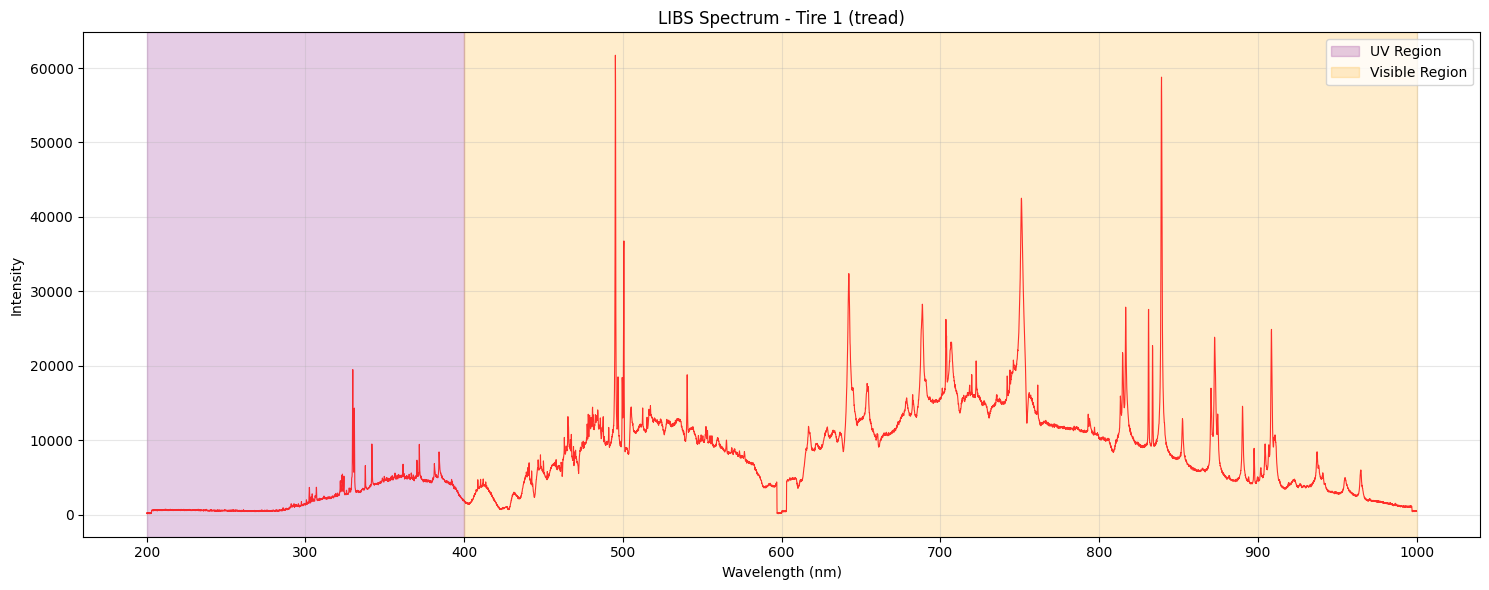

Wavelength range: 200.0 - 1000.0 nm
Intensity range: 132.0 - 61711.0
Peak intensity at wavelength: 495.3 nm


In [17]:
# Single Spectrum Plot - visualize one measurement
print("📈 Creating single spectrum visualization...")

# Get a single tire measurement for visualization
single_tire_data = df[df['tire_number'] == 1].iloc[0]

# Extract wavelength data - use the actual column names
wavelength_values = [float(col) for col in wavelength_columns]
intensity_values = [single_tire_data[col] for col in wavelength_columns]

fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(wavelength_values, intensity_values, linewidth=0.8, alpha=0.8, color='red')
ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel('Intensity')
ax.set_title(f'LIBS Spectrum - Tire {single_tire_data["tire_number"]} ({single_tire_data["origin"]})')
ax.grid(True, alpha=0.3)

# Highlight UV vs VIS regions
ax.axvspan(min(wavelength_values), 400, alpha=0.2, color='purple', label='UV Region')
ax.axvspan(400, max(wavelength_values), alpha=0.2, color='orange', label='Visible Region')
ax.legend()

plt.tight_layout()
plt.show()

print(f"Wavelength range: {min(wavelength_values):.1f} - {max(wavelength_values):.1f} nm")
print(f"Intensity range: {min(intensity_values):.1f} - {max(intensity_values):.1f}")
print(f"Peak intensity at wavelength: {wavelength_values[np.argmax(intensity_values)]:.1f} nm")

# !!!!!!!!!!!!!!!!!!!!!!!!!CEL HIERONDER MOET NOG GEFIXT WORDEN!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!

In [18]:
# # Multi-tire comparison for same component
# print("🔄 Creating multi-tire comparison...")

# # Select tread data for comparison
# tread_data = df[df['origin'] == 'tread'].copy()
# tire_numbers = sorted(tread_data['tire_number'].unique())[:2]  # First 2 tires

# fig, ax = plt.subplots(figsize=(15, 8))
# colors = plt.cm.viridis(np.linspace(0, 1, len(tire_numbers)))

# for i, tire_num in enumerate(tire_numbers):
#     tire_data = tread_data[tread_data['tire_number'] == tire_num].iloc[0]
#     intensity_values = [tread_data[col] for col in wavelength_columns]
    
#     ax.plot(wavelength_values, intensity_values, 
#             label=f'Tire {tire_num}', alpha=0.7, color=colors[i], linewidth=1)

# ax.set_xlabel('Wavelength (nm)')
# ax.set_ylabel('Intensity')
# ax.set_title('LIBS Spectra Comparison - Multiple Tires (Tread)')
# ax.legend()
# ax.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.show()

# # Statistical summary
# print("Intensity statistics by tire:")
# for tire_num in tire_numbers:
#     tire_data = tread_data[tread_data['tire_number'] == tire_num].iloc[0]
#     intensities = [tire_data[col] for col in wavelength_columns]
#     print(f"Tire {tire_num}: Mean={np.mean(intensities):.2f}, Std={np.std(intensities):.2f}, Max={np.max(intensities):.2f}")

In [19]:
# Interactive Plotly visualization
print("🎯 Creating interactive Plotly visualization...")

fig = go.Figure()

# Add traces for different components from first tire
components = df['origin'].unique()[:3]  # Take first 3 components
colors = ['blue', 'red', 'green']

for i, component in enumerate(components):
    component_data = df[df['origin'] == component].iloc[0]
    intensity_values = [component_data[col] for col in wavelength_columns]
    
    fig.add_trace(go.Scatter(
        x=wavelength_values,
        y=intensity_values,
        mode='lines',
        name=f'{component.title()}',
        line=dict(width=1, color=colors[i]),
        opacity=0.8
    ))

fig.update_layout(
    title='Interactive LIBS Spectra - Different Components',
    xaxis_title='Wavelength (nm)',
    yaxis_title='Intensity',
    width=1000,
    height=600,
    hovermode='x unified'
)

# Add UV/VIS region annotation
fig.add_vline(x=400, line_dash="dash", line_color="red", 
              annotation_text="UV/VIS Boundary", annotation_position="top")

fig.show()

🎯 Creating interactive Plotly visualization...


## Section 4: Component Comparison Analysis

Comparing spectral data across different tire components to identify distinctive patterns.

🔍 Analyzing component differences...


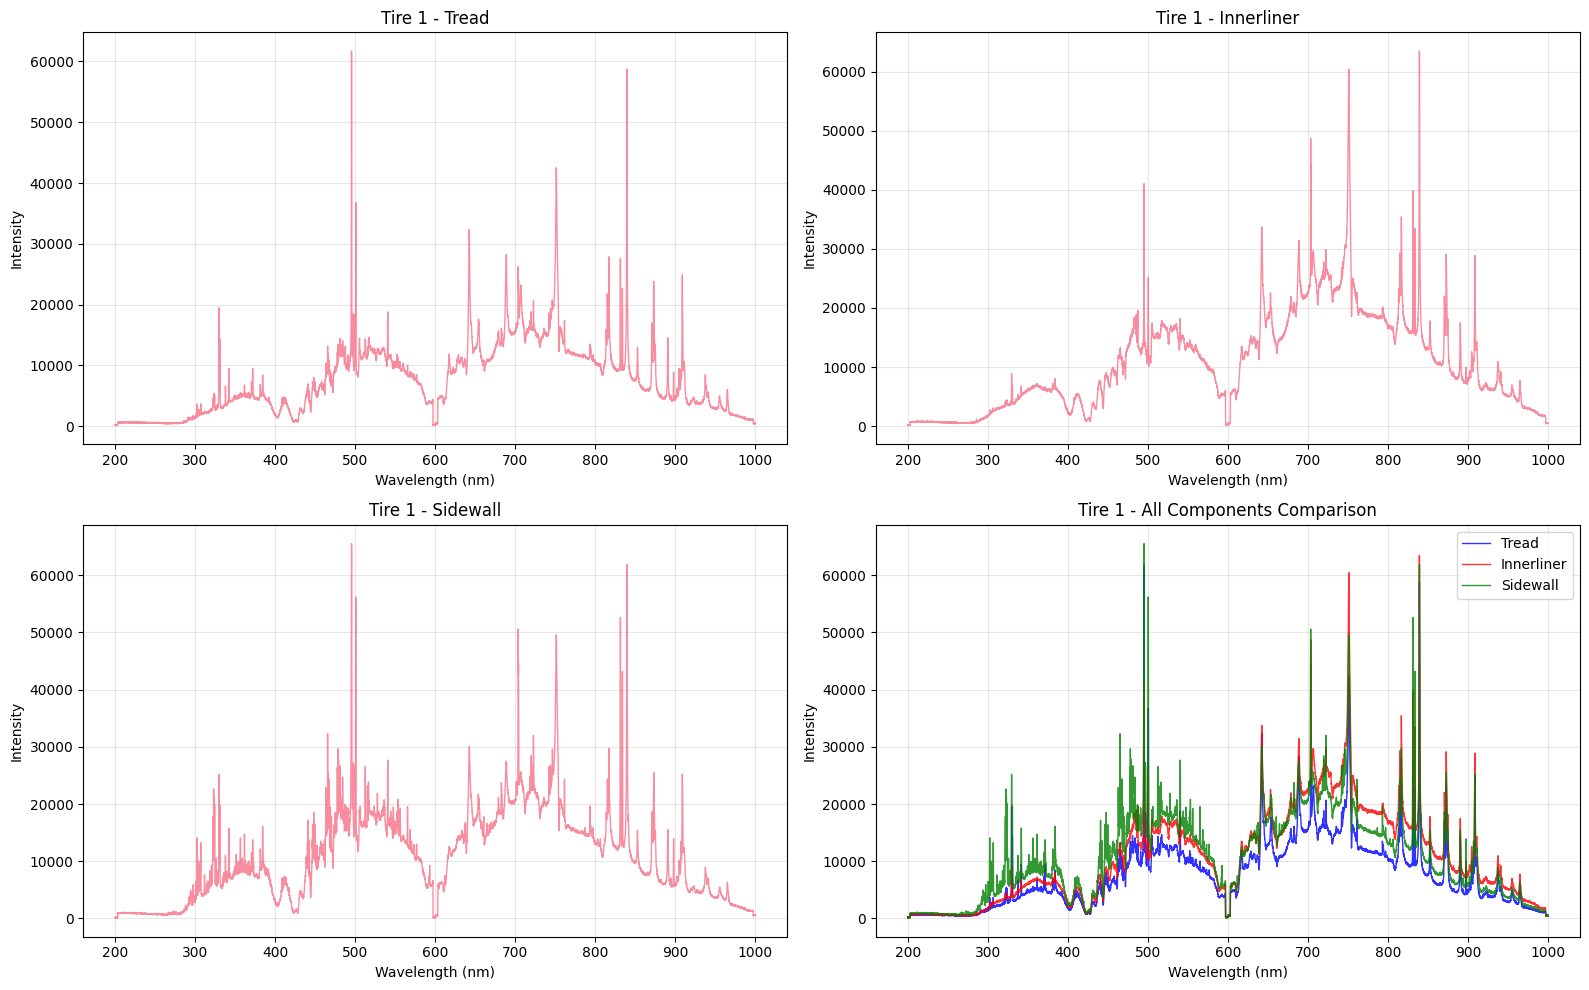

Intensity statistics for Tire 1:
Tread       : Mean=7547.41, Std=5926.44, Max=61711.00
Innerliner  : Mean=10702.28, Std=8295.24, Max=63468.00
Sidewall    : Mean=10693.77, Std=7781.23, Max=65535.00


In [20]:
# Component comparison for the same tire
print("🔍 Analyzing component differences...")

target_tire = 1
components = df['origin'].unique()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

component_data = {}
for i, component in enumerate(components):
    component_df = df[(df['origin'] == component) & (df['tire_number'] == target_tire)]
    
    if len(component_df) > 0:
        component_sample = component_df.iloc[0]
        intensity_values = [component_sample[col] for col in wavelength_columns]
        component_data[component] = intensity_values
        
        # Individual component plots
        if i < 3:  # Only plot first 3 components
            row, col = i // 2, i % 2
            axes[row, col].plot(wavelength_values, intensity_values, 
                              linewidth=1, alpha=0.8, label=component)
            axes[row, col].set_title(f'Tire {target_tire} - {component.title()}')
            axes[row, col].set_xlabel('Wavelength (nm)')
            axes[row, col].set_ylabel('Intensity')
            axes[row, col].grid(True, alpha=0.3)

# Combined comparison plot
axes[1, 1].clear()
colors = ['blue', 'red', 'green', 'orange', 'purple']
for i, (component, intensities) in enumerate(component_data.items()):
    color = colors[i % len(colors)]
    axes[1, 1].plot(wavelength_values, intensities, 
                   label=component.title(), color=color, linewidth=1, alpha=0.8)

axes[1, 1].set_title(f'Tire {target_tire} - All Components Comparison')
axes[1, 1].set_xlabel('Wavelength (nm)')
axes[1, 1].set_ylabel('Intensity')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Statistical comparison
print(f"Intensity statistics for Tire {target_tire}:")
for component, intensities in component_data.items():
    print(f"{component.title():12}: Mean={np.mean(intensities):.2f}, "
          f"Std={np.std(intensities):.2f}, Max={np.max(intensities):.2f}")

## Section 5: Baseline Correction Implementation

Implementing advanced baseline correction algorithms to improve spectral data quality.

🔄 Applying baseline correction to component data...
Applying HYBRID baseline correction to 2 spectra in batches of 100...
  Processing batch 1/1 (spectra 1-2)
✅ Applied baseline correction to tread
Applying HYBRID baseline correction to 2 spectra in batches of 100...
  Processing batch 1/1 (spectra 1-2)
✅ Applied baseline correction to innerliner
Applying HYBRID baseline correction to 2 spectra in batches of 100...
  Processing batch 1/1 (spectra 1-2)
✅ Applied baseline correction to sidewall


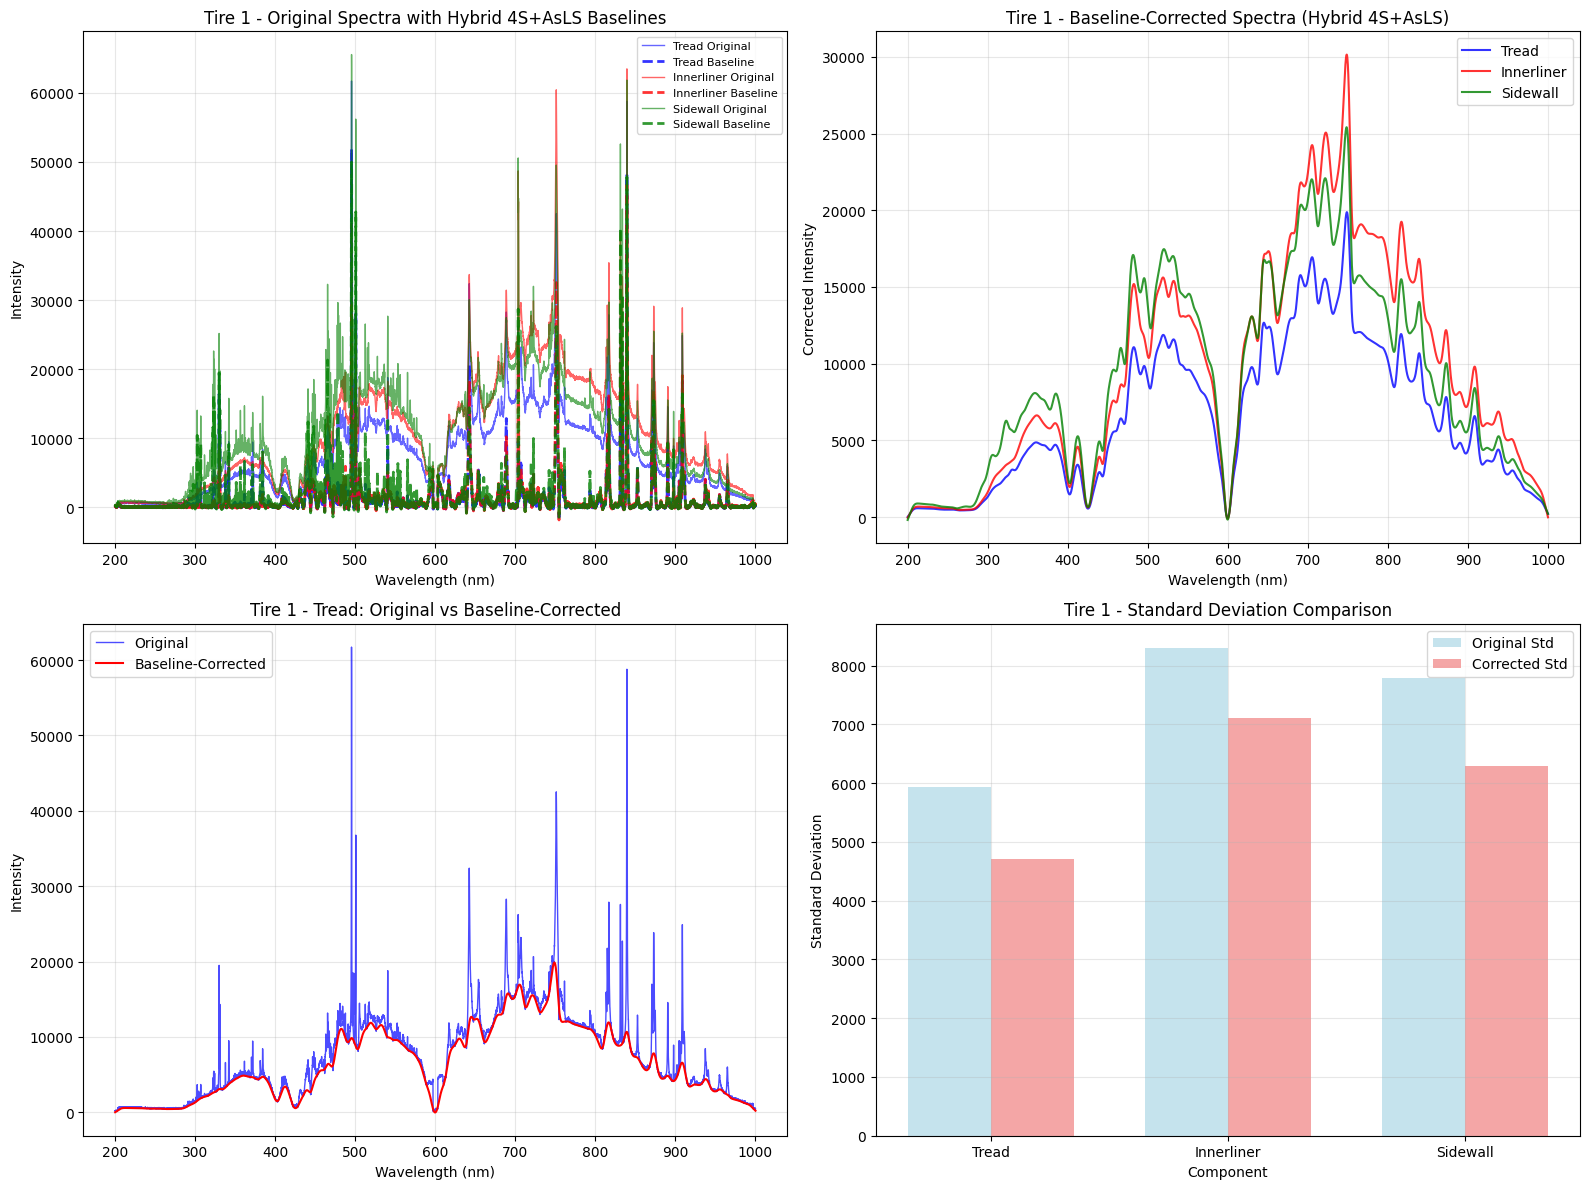


=== BASELINE CORRECTION EFFECT ANALYSIS - Tire 1 ===
Component    Orig Std   Corr Std   Std Reduction
--------------------------------------------------
Tread        5926.4     4715.8     20.4        %
Innerliner   8295.2     7099.6     14.4        %
Sidewall     7781.2     6288.4     19.2        %


In [27]:
# Apply baseline correction to component data
print("🔄 Applying baseline correction to component data...")

target_tire = 1
corrected_components = []

for component in components:
    component_df = df[(df['origin'] == component) & (df['tire_number'] == target_tire)]
    
    if len(component_df) > 0:
        component_sample = component_df.iloc[0]
        intensities = np.array([component_sample[col] for col in wavelength_columns])
        spectra_matrix = np.array([
            np.array(wavelength_values),  # Row 0: wavelengths
            intensities                   # Row 1: intensities
        ])
        # Apply baseline correction
        baseline = baseline_corrector.apply_correction_batch(spectra_matrix, 
                                         method='hybrid',
                                         batch_size=100,
                                         window_length=51, 
                                         polyorder=3, 
                                         als_lam=1e4, 
                                         als_p=0.01)
        # Extract the baseline for intensities (row 1) if baseline is 2D
        if baseline.ndim == 2:
            baseline_intensities = baseline[1]  # Get intensity baseline
        else:
            baseline_intensities = baseline
        corrected_intensities = intensities - baseline_intensities
        
        corrected_components.append({
            'component': component,
            'wavelengths': wavelength_values,
            'original': intensities,
            'baseline': baseline,
            'corrected': corrected_intensities
        })
        print(f"✅ Applied baseline correction to {component}")

# Visualize baseline correction results
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

colors = ['blue', 'red', 'green']

# Plot 1: Original spectra with baselines
for i, comp_data in enumerate(corrected_components[:3]):
    color = colors[i % len(colors)]
    axes[0, 0].plot(comp_data['wavelengths'], comp_data['original'], 
                color=color, alpha=0.6, linewidth=1, 
                label=f'{comp_data["component"].title()} Original')
    
    # Extract baseline intensities for plotting
    if comp_data['baseline'].ndim == 2:
        baseline_intensities = comp_data['baseline'][1]  # Get intensity baseline
    else:
        baseline_intensities = comp_data['baseline']
        
    axes[0, 0].plot(comp_data['wavelengths'], baseline_intensities, 
                color=color, linestyle='--', linewidth=2, alpha=0.8, 
                label=f'{comp_data["component"].title()} Baseline')

axes[0, 0].set_title(f'Tire {target_tire} - Original Spectra with Hybrid 4S+AsLS Baselines')
axes[0, 0].set_xlabel('Wavelength (nm)')
axes[0, 0].set_ylabel('Intensity')
axes[0, 0].legend(fontsize=8)
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Baseline-corrected spectra only
for i, comp_data in enumerate(corrected_components[:3]):
    color = colors[i % len(colors)]
    axes[0, 1].plot(comp_data['wavelengths'], comp_data['corrected'], 
                    color=color, linewidth=1.5, alpha=0.8, 
                    label=comp_data["component"].title())

axes[0, 1].set_title(f'Tire {target_tire} - Baseline-Corrected Spectra (Hybrid 4S+AsLS)')
axes[0, 1].set_xlabel('Wavelength (nm)')
axes[0, 1].set_ylabel('Corrected Intensity')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Comparison - Original vs Corrected for one component
if corrected_components:
    comp_data = corrected_components[0]  # Use first component
    
    axes[1, 0].plot(comp_data['wavelengths'], comp_data['original'], 
                    'b-', alpha=0.7, label='Original', linewidth=1)
    axes[1, 0].plot(comp_data['wavelengths'], comp_data['corrected'], 
                    'r-', label='Baseline-Corrected', linewidth=1.5)
    axes[1, 0].set_title(f'Tire {target_tire} - {comp_data["component"].title()}: Original vs Baseline-Corrected')
    axes[1, 0].set_xlabel('Wavelength (nm)')
    axes[1, 0].set_ylabel('Intensity')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Statistical comparison
correction_stats = []
for comp_data in corrected_components:
    stats = {
        'Component': comp_data['component'].title(),
        'Original_Std': np.std(comp_data['original']),
        'Corrected_Std': np.std(comp_data['corrected'])
    }
    correction_stats.append(stats)

if correction_stats:
    components_names = [stats['Component'] for stats in correction_stats]
    original_stds = [stats['Original_Std'] for stats in correction_stats]
    corrected_stds = [stats['Corrected_Std'] for stats in correction_stats]
    
    x_pos = np.arange(len(components_names))
    width = 0.35
    
    bars1 = axes[1, 1].bar(x_pos - width/2, original_stds, width, 
                          label='Original Std', alpha=0.7, color='lightblue')
    bars2 = axes[1, 1].bar(x_pos + width/2, corrected_stds, width, 
                          label='Corrected Std', alpha=0.7, color='lightcoral')
    
    axes[1, 1].set_title(f'Tire {target_tire} - Standard Deviation Comparison')
    axes[1, 1].set_xlabel('Component')
    axes[1, 1].set_ylabel('Standard Deviation')
    axes[1, 1].set_xticks(x_pos)
    axes[1, 1].set_xticklabels(components_names)
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print statistical comparison
print(f"\n=== BASELINE CORRECTION EFFECT ANALYSIS - Tire {target_tire} ===")
print(f"{'Component':<12} {'Orig Std':<10} {'Corr Std':<10} {'Std Reduction':<12}")
print("-" * 50)

for stats in correction_stats:
    orig_std = stats['Original_Std']
    corr_std = stats['Corrected_Std']
    std_reduction = (orig_std - corr_std) / orig_std * 100
    
    print(f"{stats['Component']:<12} {orig_std:<10.1f} {corr_std:<10.1f} {std_reduction:<12.1f}%")

## Section 6: Statistical Distribution Analysis

Analyzing the statistical distributions of intensity values and identifying patterns across wavelengths.

📊 Performing statistical distribution analysis...


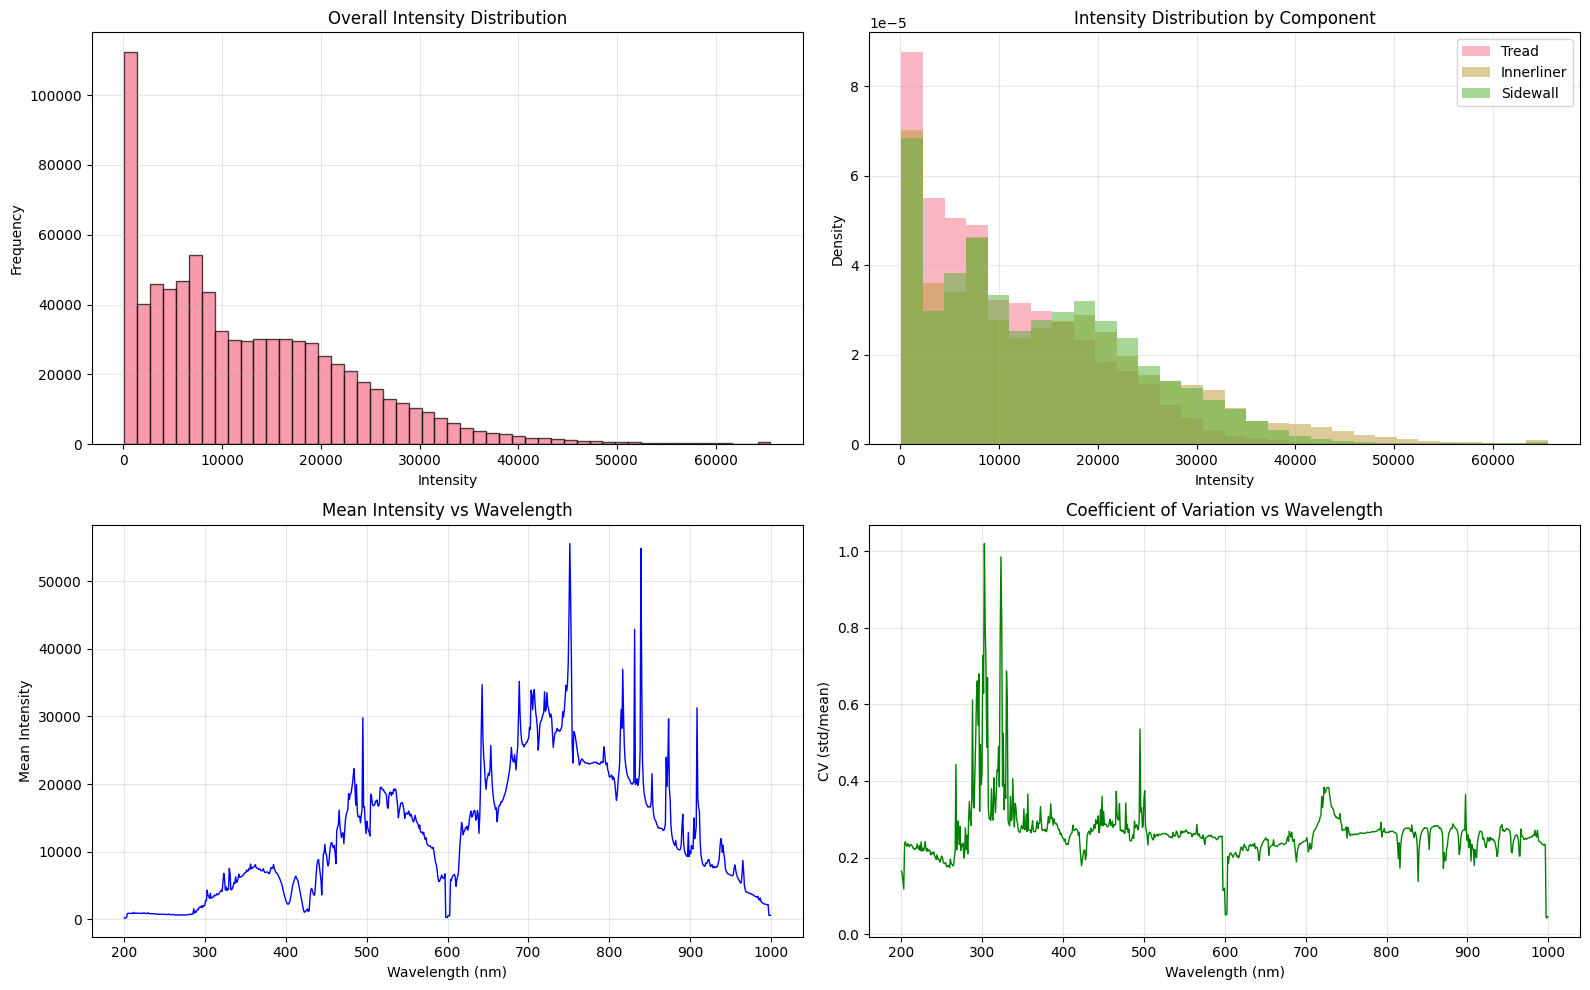

Analysis completed on 819000 data points
Mean intensity: 12636.41
Std intensity: 10447.77
Intensity range: 96.00 - 65535.00


In [28]:
# Statistical distribution analysis
print("📊 Performing statistical distribution analysis...")

# Create a long-format dataframe for analysis
analysis_data = []
for _, row in df.head(1000).iterrows():  # Sample first 1000 rows for performance
    for wl_col in wavelength_columns[::10]:  # Sample every 10th wavelength column
        analysis_data.append({
            'wavelength': float(wl_col),
            'intensity': row[wl_col],
            'origin': row['origin'],
            'tire_number': row['tire_number']
        })

analysis_df = pd.DataFrame(analysis_data)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Overall intensity distribution
axes[0, 0].hist(analysis_df['intensity'], bins=50, alpha=0.7, edgecolor='black')
axes[0, 0].set_title('Overall Intensity Distribution')
axes[0, 0].set_xlabel('Intensity')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].grid(True, alpha=0.3)

# 2. Intensity distribution by component
for i, component in enumerate(analysis_df['origin'].unique()):
    component_data = analysis_df[analysis_df['origin'] == component]
    axes[0, 1].hist(component_data['intensity'], bins=30, alpha=0.5, 
                   label=component.title(), density=True)

axes[0, 1].set_title('Intensity Distribution by Component')
axes[0, 1].set_xlabel('Intensity')
axes[0, 1].set_ylabel('Density')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Mean intensity vs wavelength
mean_intensity = analysis_df.groupby('wavelength')['intensity'].mean()
axes[1, 0].plot(mean_intensity.index, mean_intensity.values, 'b-', linewidth=1)
axes[1, 0].set_title('Mean Intensity vs Wavelength')
axes[1, 0].set_xlabel('Wavelength (nm)')
axes[1, 0].set_ylabel('Mean Intensity')
axes[1, 0].grid(True, alpha=0.3)

# 4. Coefficient of variation across wavelengths
cv_data = analysis_df.groupby('wavelength')['intensity'].agg(['mean', 'std'])
cv_data['cv'] = cv_data['std'] / cv_data['mean']

axes[1, 1].plot(cv_data.index, cv_data['cv'], 'g-', linewidth=1)
axes[1, 1].set_title('Coefficient of Variation vs Wavelength')
axes[1, 1].set_xlabel('Wavelength (nm)')
axes[1, 1].set_ylabel('CV (std/mean)')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Analysis completed on {len(analysis_df)} data points")
print(f"Mean intensity: {analysis_df['intensity'].mean():.2f}")
print(f"Std intensity: {analysis_df['intensity'].std():.2f}")
print(f"Intensity range: {analysis_df['intensity'].min():.2f} - {analysis_df['intensity'].max():.2f}")

# ALLES HIERONDER NOG EEN KEER DOEN MAAR DAN MET BASELINE CORRECTED DATA

## Section 7: Peak Detection and Identification

Using advanced peak detection algorithms to identify important wavelengths in the spectral data.

🎯 Performing peak detection analysis...


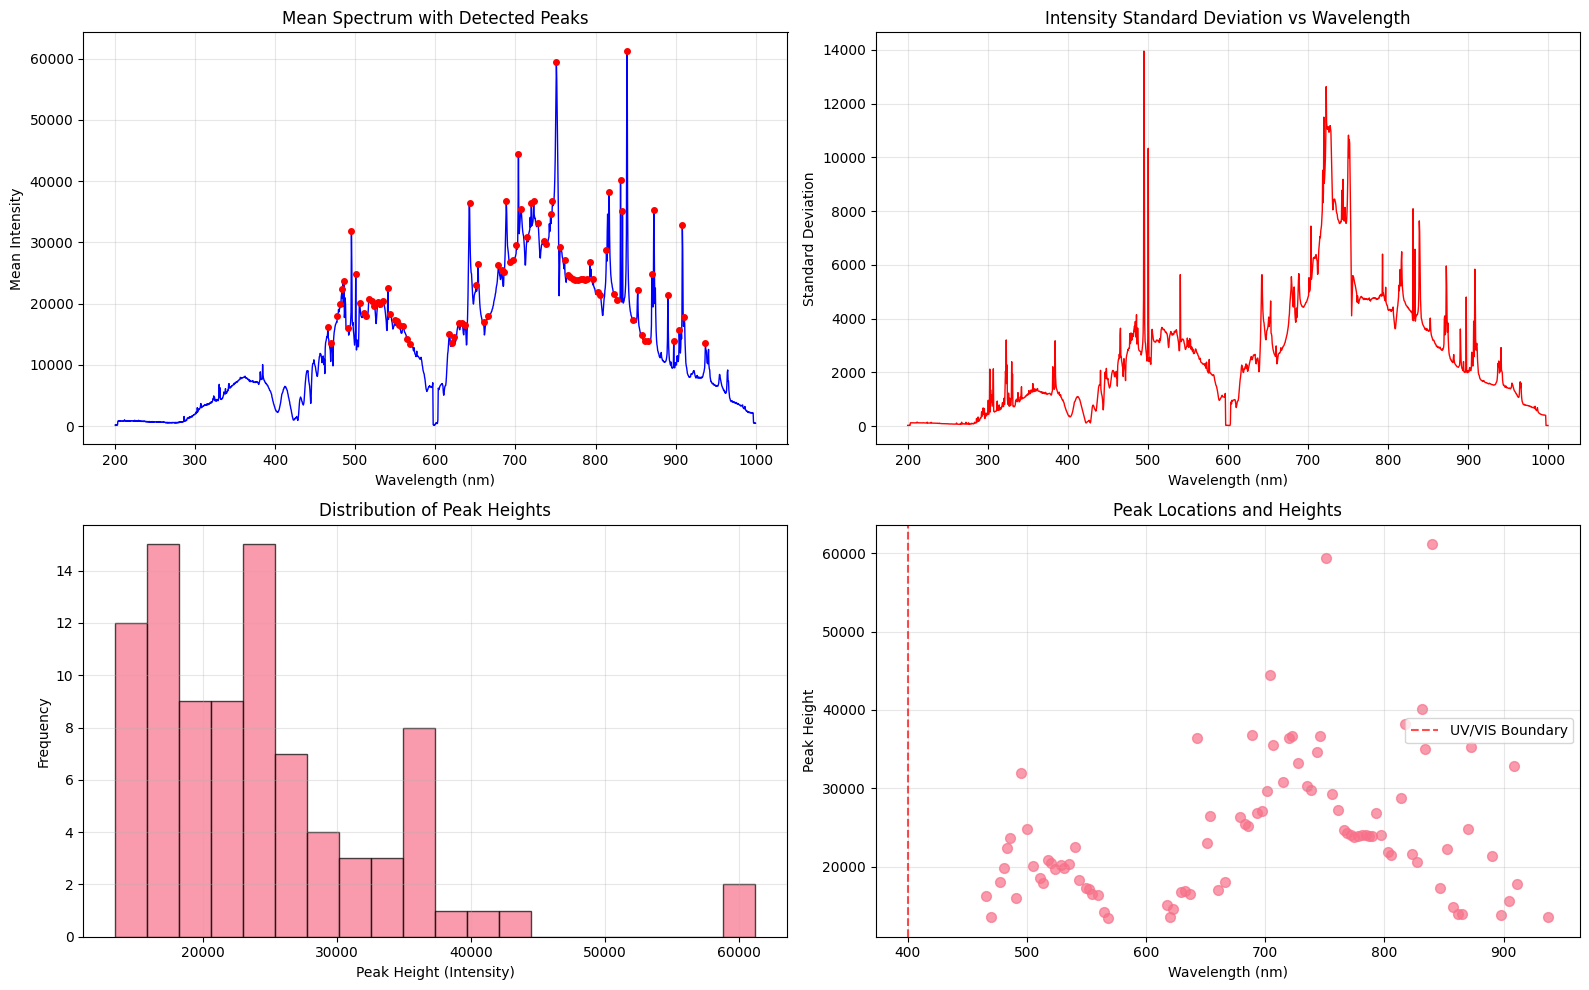

Found 90 peaks in the mean spectrum
Top 10 peak wavelengths: [465.787 470.184 477.513 480.933 483.376 485.819 491.193 495.102 500.476
 505.362]

Peak distribution:
UV region (< 400nm): 0 peaks
VIS region (≥ 400nm): 90 peaks


In [29]:
# Peak detection and identification
print("🎯 Performing peak detection analysis...")

# Calculate mean spectrum across all samples
mean_spectrum_data = []
for wl in wavelength_values[::5]:  # Sample every 5th wavelength for performance
    wl_intensities = []
    # Format wavelength to match column names (3 decimal places)
    wl_col = f"{wl:.3f}"
    for _, row in df.head(500).iterrows():  # Sample first 500 rows
        wl_intensities.append(row[wl_col])
    
    mean_spectrum_data.append({
        'wavelength': wl,
        'mean_intensity': np.mean(wl_intensities),
        'std_intensity': np.std(wl_intensities)
    })

mean_spectrum_df = pd.DataFrame(mean_spectrum_data)

# Find peaks in the mean spectrum
peaks, properties = find_peaks(mean_spectrum_df['mean_intensity'].values, 
                              height=mean_spectrum_df['mean_intensity'].mean(), 
                              distance=5)
peak_wavelengths = mean_spectrum_df.iloc[peaks]['wavelength'].values

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Mean spectrum with peaks
axes[0, 0].plot(mean_spectrum_df['wavelength'], mean_spectrum_df['mean_intensity'], 'b-', linewidth=1)
axes[0, 0].plot(peak_wavelengths, mean_spectrum_df.iloc[peaks]['mean_intensity'], 'ro', markersize=4)
axes[0, 0].set_title('Mean Spectrum with Detected Peaks')
axes[0, 0].set_xlabel('Wavelength (nm)')
axes[0, 0].set_ylabel('Mean Intensity')
axes[0, 0].grid(True, alpha=0.3)

# 2. Standard deviation across wavelengths
axes[0, 1].plot(mean_spectrum_df['wavelength'], mean_spectrum_df['std_intensity'], 'r-', linewidth=1)
axes[0, 1].set_title('Intensity Standard Deviation vs Wavelength')
axes[0, 1].set_xlabel('Wavelength (nm)')
axes[0, 1].set_ylabel('Standard Deviation')
axes[0, 1].grid(True, alpha=0.3)

# 3. Peak height distribution
peak_heights = mean_spectrum_df.iloc[peaks]['mean_intensity'].values
axes[1, 0].hist(peak_heights, bins=20, alpha=0.7, edgecolor='black')
axes[1, 0].set_title('Distribution of Peak Heights')
axes[1, 0].set_xlabel('Peak Height (Intensity)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].grid(True, alpha=0.3)

# 4. Peak locations across spectrum
axes[1, 1].scatter(peak_wavelengths, peak_heights, alpha=0.7, s=50)
axes[1, 1].set_title('Peak Locations and Heights')
axes[1, 1].set_xlabel('Wavelength (nm)')
axes[1, 1].set_ylabel('Peak Height')
axes[1, 1].axvline(x=400, color='red', linestyle='--', alpha=0.7, label='UV/VIS Boundary')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Found {len(peak_wavelengths)} peaks in the mean spectrum")
print(f"Top 10 peak wavelengths: {peak_wavelengths[:10]}")

# Analyze UV vs VIS peaks
uv_peaks = peak_wavelengths[peak_wavelengths < 400]
vis_peaks = peak_wavelengths[peak_wavelengths >= 400]
print(f"\nPeak distribution:")
print(f"UV region (< 400nm): {len(uv_peaks)} peaks")
print(f"VIS region (≥ 400nm): {len(vis_peaks)} peaks")

## Section 8: Information Gain Calculation

Implementing information theory methods to calculate the discriminative power of wavelengths.

In [30]:
# Information gain calculation functions
def entropy(y):
    """Calculate entropy of target variable"""
    counts = Counter(y)
    probabilities = [count/len(y) for count in counts.values()]
    return -sum(p * np.log2(p) for p in probabilities if p > 0)

def information_gain_single_feature(y, x):
    """Calculate information gain for a single feature"""
    total_entropy = entropy(y)
    
    # For continuous features, discretize using quantile-based binning
    n_bins = min(10, len(np.unique(x)))
    if n_bins <= 1:
        return 0.0
    
    try:
        # Create bins using quantiles
        bins = np.quantile(x, np.linspace(0, 1, n_bins + 1))
        bins = np.unique(bins)
        
        if len(bins) <= 1:
            return 0.0
            
        # Digitize the continuous values into bins
        x_binned = np.digitize(x, bins[1:-1])
        
    except Exception:
        # Fallback: use simple binning
        x_binned = pd.cut(x, bins=n_bins, labels=False, duplicates='drop')
        if x_binned is None:
            return 0.0
    
    # Calculate weighted entropy after split
    unique_values, counts = np.unique(x_binned, return_counts=True)
    weighted_entropy = 0
    
    for value, count in zip(unique_values, counts):
        if count == 0:
            continue
        mask = (x_binned == value)
        y_subset = y[mask]
        if len(y_subset) > 0:
            weighted_entropy += (count / len(x)) * entropy(y_subset)
    
    return total_entropy - weighted_entropy

print("✅ Information gain calculation functions implemented")

✅ Information gain calculation functions implemented


In [31]:
def calculate_component_specific_importance(df, wavelength_list, components, top_n=100):
    """
    Calculate information gain for each wavelength within each component separately
    This analyzes which wavelengths best distinguish between different tires within each component
    """
    
    component_results = {}
    
    for component in components:
        print(f"\n🔍 Calculating information gain for {component.upper()} component...")
        
        # Filter data for this component only
        component_df = df[df['origin'] == component].copy()
        
        if len(component_df) == 0:
            print(f"❌ No data found for component: {component}")
            continue
            
        print(f"   Dataset shape for {component}: {component_df.shape}")
        print(f"   Unique tires in {component}: {component_df['tire_number'].nunique()}")
        
        # Use tire_number as target for within-component analysis
        y = component_df['tire_number'].values
        
        wavelength_scores = []
        
        # Process wavelengths in batches
        batch_size = 50
        n_batches = len(wavelength_list) // batch_size + 1
        
        for batch_idx in range(n_batches):
            start_idx = batch_idx * batch_size
            end_idx = min(start_idx + batch_size, len(wavelength_list))
            batch_wavelengths = wavelength_list[start_idx:end_idx]
            
            if batch_idx % 10 == 0:
                print(f"   Processing batch {batch_idx + 1}/{n_batches} for {component}")
            
            for wl in batch_wavelengths:
                try:
                    # Format wavelength to match column names
                    wl_col = f"{wl:.3f}"
                    
                    if wl_col not in component_df.columns:
                        continue
                    
                    # Get intensity data for this wavelength
                    intensities = component_df[wl_col].values
                    
                    # Skip if all values are the same
                    if len(np.unique(intensities)) <= 1:
                        continue
                    
                    # Calculate information gain
                    ig_score = information_gain_single_feature(y, intensities)
                    
                    wavelength_scores.append({
                        'wavelength': wl,
                        'information_gain': ig_score,
                        'n_samples': len(intensities),
                        'intensity_mean': np.mean(intensities),
                        'intensity_std': np.std(intensities),
                        'n_unique_tires': len(np.unique(y))
                    })
                    
                except Exception as e:
                    continue
        
        # Create results DataFrame for this component
        if wavelength_scores:
            results_df = pd.DataFrame(wavelength_scores)
            results_df = results_df.sort_values('information_gain', ascending=False)
            
            component_results[component] = results_df.head(top_n)
            
            print(f"✅ {component}: Processed {len(results_df)} wavelengths")
            print(f"   Top information gain: {results_df['information_gain'].max():.4f}")
            print(f"   Mean information gain: {results_df['information_gain'].mean():.4f}")
        else:
            print(f"❌ No valid wavelengths processed for {component}")
            component_results[component] = pd.DataFrame()
    
    return component_results

# Calculate importance for each component separately
print("🚀 Starting component-specific wavelength importance analysis...")

# Use every 5th wavelength for better coverage while maintaining performance
analysis_wavelengths = wavelength_values[::5]  # Every 5th wavelength
components = df['origin'].unique()

component_importance_results = calculate_component_specific_importance(
    df.head(100000),  # Use first 1000 rows for performance
    analysis_wavelengths,
    components,
    top_n=100
)

🚀 Starting component-specific wavelength importance analysis...

🔍 Calculating information gain for TREAD component...
   Dataset shape for tread: (17936, 8191)
   Unique tires in tread: 103
   Processing batch 1/33 for tread
   Processing batch 11/33 for tread
   Processing batch 21/33 for tread
   Processing batch 31/33 for tread
✅ tread: Processed 1638 wavelengths
   Top information gain: 0.9501
   Mean information gain: 0.6924

🔍 Calculating information gain for INNERLINER component...
   Dataset shape for innerliner: (17260, 8191)
   Unique tires in innerliner: 103
   Processing batch 1/33 for innerliner
   Processing batch 11/33 for innerliner
   Processing batch 21/33 for innerliner
   Processing batch 31/33 for innerliner
✅ innerliner: Processed 1638 wavelengths
   Top information gain: 1.3013
   Mean information gain: 0.9917

🔍 Calculating information gain for SIDEWALL component...
   Dataset shape for sidewall: (16257, 8191)
   Unique tires in sidewall: 102
   Processing batc


🔍 CROSS-COMPONENT COMPARISON

🎯 CROSS-COMPONENT IMPORTANT WAVELENGTHS:
Wavelengths important in multiple components: 8
Common important wavelengths: [345.597, 358.3, 360.743, 839.551, 872.774, 873.262, 908.44, 908.929]...

Top 5 wavelengths common across components:
           information_gain                                  component
                       mean     std count                     <lambda>
wavelength                                                            
908.440              1.1198  0.1654     3  tread, innerliner, sidewall
839.551              1.1196  0.1664     3  tread, innerliner, sidewall
872.774              1.1129  0.1496     3  tread, innerliner, sidewall
908.929              1.1088  0.1760     3  tread, innerliner, sidewall
873.262              1.0129  0.1694     2              tread, sidewall


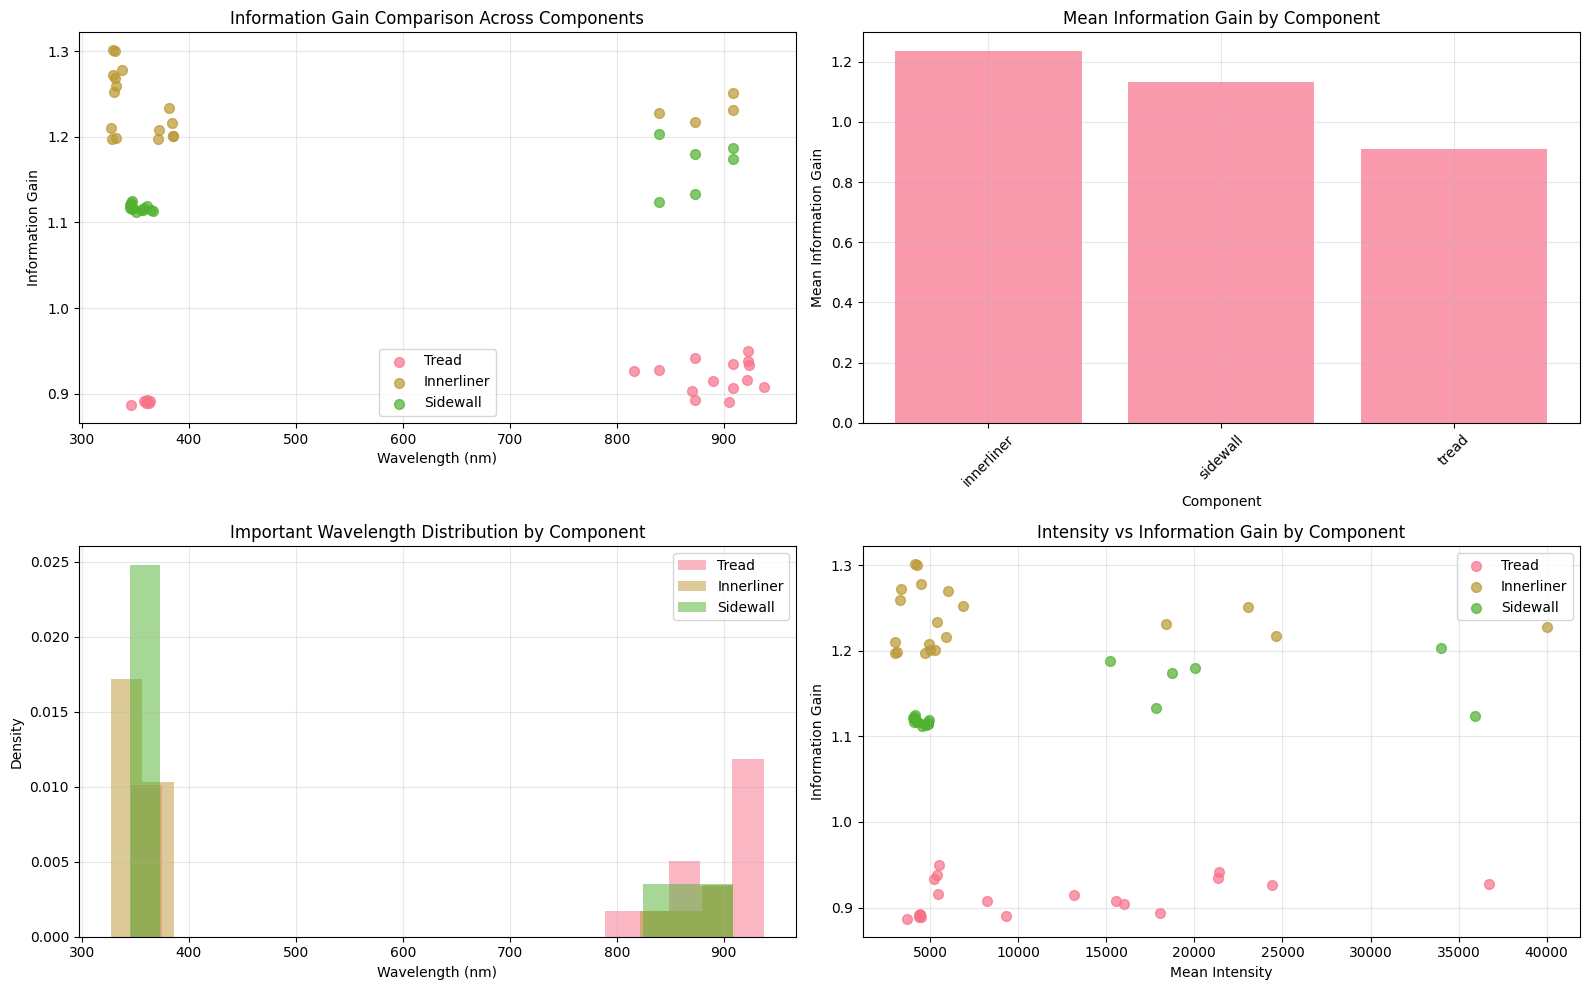


🎉 COMPONENT-SPECIFIC ANALYSIS COMPLETED!
💡 Key Insights:
   • Each component has unique wavelength signatures
   • Some wavelengths are important across multiple components
   • Results can guide component-specific feature selection
   • Consider ensemble approaches using component-specific models


In [32]:
def compare_components(component_results):
    """Compare wavelength importance across components and export results"""
    
    print(f"\n🔍 CROSS-COMPONENT COMPARISON")
    print("=" * 60)
    
    # Create comparison DataFrame
    comparison_data = []
    
    for component, importance_df in component_results.items():
        if len(importance_df) == 0:
            continue
            
        # Get top wavelengths for this component
        top_wavelengths = importance_df.head(20)
        
        for _, row in top_wavelengths.iterrows():
            comparison_data.append({
                'component': component,
                'wavelength': row['wavelength'],
                'information_gain': row['information_gain'],
                'rank_in_component': top_wavelengths.index.get_loc(_) + 1,
                'intensity_mean': row['intensity_mean'],
                'intensity_std': row['intensity_std']
            })
    
    comparison_df = pd.DataFrame(comparison_data)
    
    if len(comparison_df) > 0:
        # Find wavelengths that are important across multiple components
        wavelength_counts = comparison_df['wavelength'].value_counts()
        common_wavelengths = wavelength_counts[wavelength_counts > 1].index
        
        print(f"\n🎯 CROSS-COMPONENT IMPORTANT WAVELENGTHS:")
        print(f"Wavelengths important in multiple components: {len(common_wavelengths)}")
        
        if len(common_wavelengths) > 0:
            print(f"Common important wavelengths: {sorted(common_wavelengths.tolist())[:10]}...")
            
            # Analyze common wavelengths
            common_analysis = comparison_df[comparison_df['wavelength'].isin(common_wavelengths)]
            common_summary = common_analysis.groupby('wavelength').agg({
                'information_gain': ['mean', 'std', 'count'],
                'component': lambda x: ', '.join(x.unique())
            }).round(4)
            
            print(f"\nTop 5 wavelengths common across components:")
            common_summary_sorted = common_summary.sort_values(('information_gain', 'mean'), ascending=False)
            print(common_summary_sorted.head())
    
    # Create summary visualization
    if len(comparison_df) > 0:
        fig, axes = plt.subplots(2, 2, figsize=(16, 10))
        
        # 1. Information gain comparison across components
        components = comparison_df['component'].unique()
        for i, component in enumerate(components):
            comp_data = comparison_df[comparison_df['component'] == component]
            axes[0, 0].scatter(comp_data['wavelength'], comp_data['information_gain'], 
                             label=component.title(), alpha=0.7, s=50)
        
        axes[0, 0].set_xlabel('Wavelength (nm)')
        axes[0, 0].set_ylabel('Information Gain')
        axes[0, 0].set_title('Information Gain Comparison Across Components')
        axes[0, 0].legend()
        axes[0, 0].grid(True, alpha=0.3)
        
        # 2. Mean information gain by component
        component_means = comparison_df.groupby('component')['information_gain'].mean()
        axes[0, 1].bar(component_means.index, component_means.values, alpha=0.7)
        axes[0, 1].set_xlabel('Component')
        axes[0, 1].set_ylabel('Mean Information Gain')
        axes[0, 1].set_title('Mean Information Gain by Component')
        axes[0, 1].tick_params(axis='x', rotation=45)
        axes[0, 1].grid(True, alpha=0.3)
        
        # 3. Wavelength distribution by component
        for i, component in enumerate(components):
            comp_data = comparison_df[comparison_df['component'] == component]
            axes[1, 0].hist(comp_data['wavelength'], bins=20, alpha=0.5, 
                           label=component.title(), density=True)
        
        axes[1, 0].set_xlabel('Wavelength (nm)')
        axes[1, 0].set_ylabel('Density')
        axes[1, 0].set_title('Important Wavelength Distribution by Component')
        axes[1, 0].legend()
        axes[1, 0].grid(True, alpha=0.3)
        
        # 4. Intensity vs Information Gain
        for i, component in enumerate(components):
            comp_data = comparison_df[comparison_df['component'] == component]
            axes[1, 1].scatter(comp_data['intensity_mean'], comp_data['information_gain'], 
                             label=component.title(), alpha=0.7, s=50)
        
        axes[1, 1].set_xlabel('Mean Intensity')
        axes[1, 1].set_ylabel('Information Gain')
        axes[1, 1].set_title('Intensity vs Information Gain by Component')
        axes[1, 1].legend()
        axes[1, 1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
    
    # # Export results for each component
    # for component, importance_df in component_results.items():
    #     if len(importance_df) == 0:
    #         continue
            
    #     output_file = f'wavelength_importance_{component}_component.csv'
    #     importance_df.to_csv(output_file, index=False)
    #     print(f"✅ {component.title()} results saved to: {output_file}")
    
    # # Export comparison results
    # if len(comparison_df) > 0:
    #     comparison_df.to_csv('wavelength_importance_component_comparison.csv', index=False)
    #     print(f"✅ Component comparison saved to: wavelength_importance_component_comparison.csv")
    
    return comparison_df

# Perform comparison and export
comparison_results = compare_components(component_importance_results)

print(f"\n🎉 COMPONENT-SPECIFIC ANALYSIS COMPLETED!")
print(f"💡 Key Insights:")
print(f"   • Each component has unique wavelength signatures")
print(f"   • Some wavelengths are important across multiple components")
print(f"   • Results can guide component-specific feature selection")
print(f"   • Consider ensemble approaches using component-specific models")


📊 Creating information gain density plots for all wavelengths...


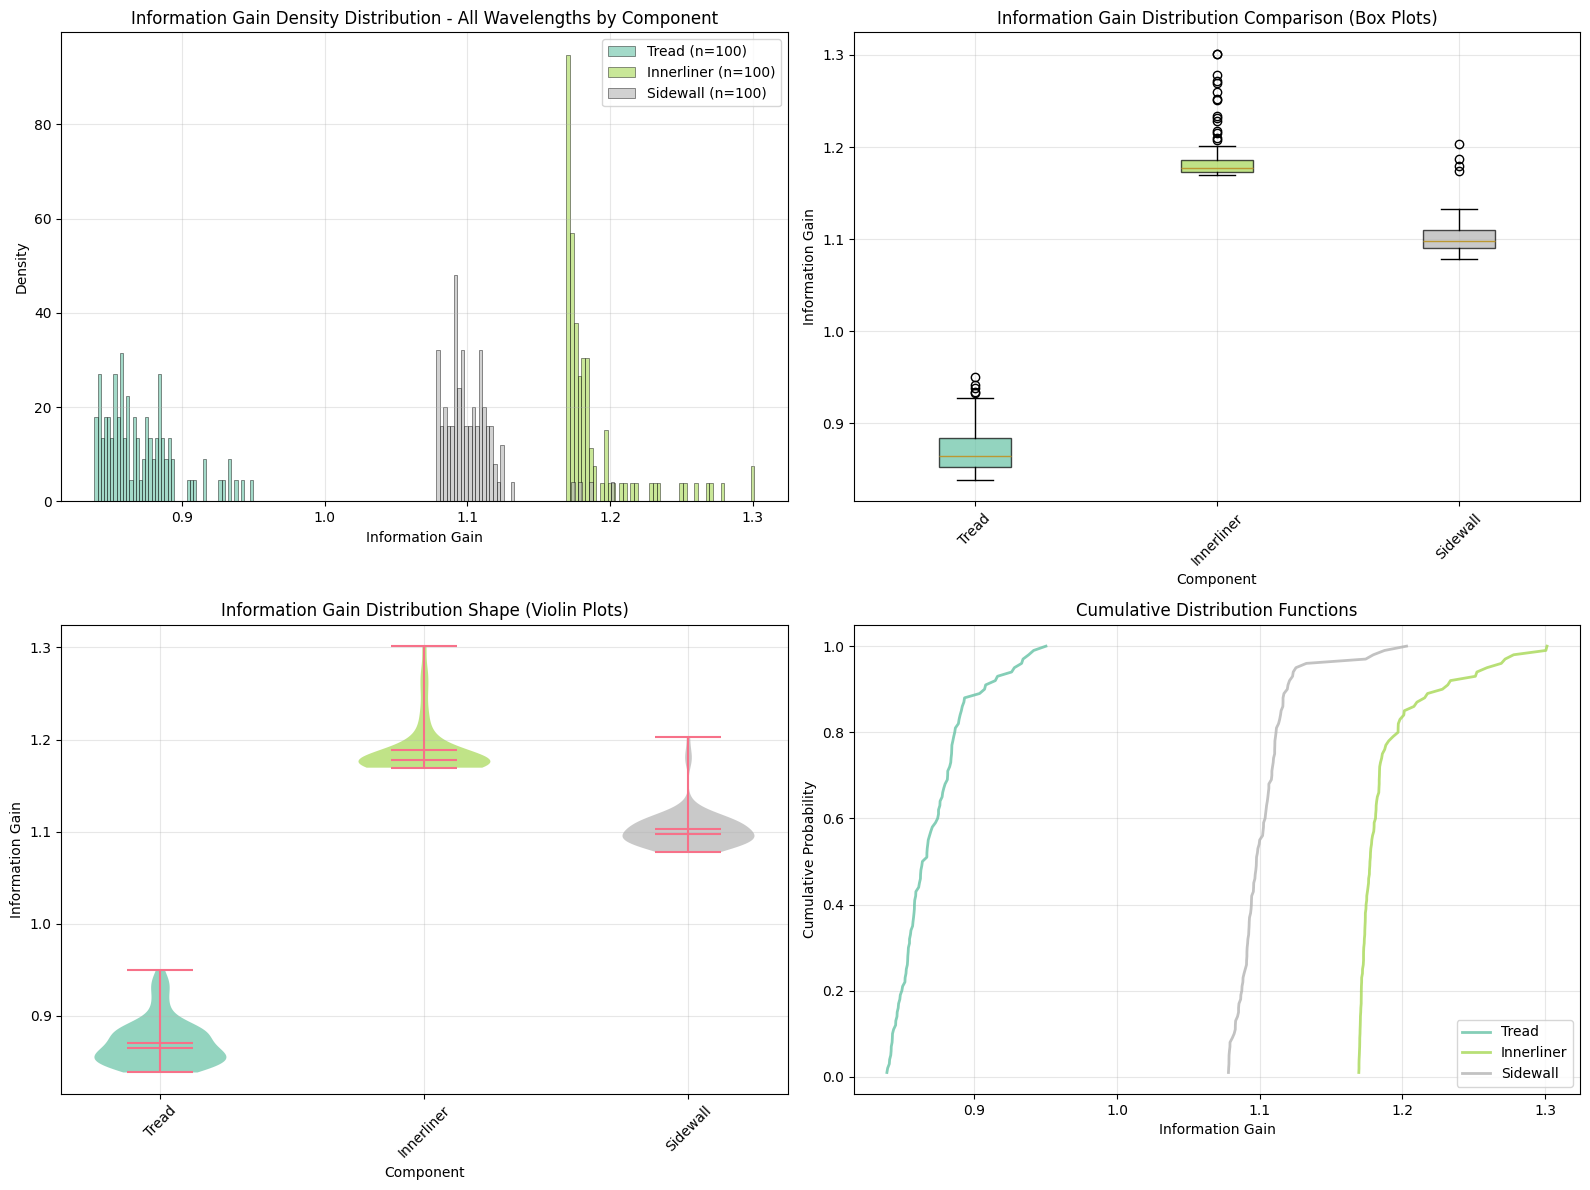


📈 STATISTICAL COMPARISON OF ALL WAVELENGTHS
Component    Count    Mean       Std        Min        Max        Median    
--------------------------------------------------------------------------------
Tread        100      0.8711     0.0254     0.8387     0.9501     0.8651    
Innerliner   100      1.1885     0.0287     1.1694     1.3013     1.1774    
Sidewall     100      1.1024     0.0213     1.0781     1.2029     1.0977    

🔬 DISTRIBUTION ANALYSIS:
Tread vs Innerliner:
  • Mean difference: -0.3174
  • Cohen's d (effect size): -11.7019
  • Effect size: large
Tread vs Sidewall:
  • Mean difference: -0.2313
  • Cohen's d (effect size): -9.8658
  • Effect size: large
Innerliner vs Sidewall:
  • Mean difference: 0.0861
  • Cohen's d (effect size): 3.4034
  • Effect size: large

📊 PERCENTILE ANALYSIS:
Component   P10     P25     P50     P75     P90     P95     P99     
--------------------------------------------------------------------
Tread       0.8433  0.8528  0.8651  0.8840  0.90

In [33]:
def visualize_information_gain_density_all_wavelengths(component_results):
    """
    Create density plots showing the distribution of information gain scores 
    for ALL wavelengths per component (not just top wavelengths)
    """
    
    print(f"\n📊 Creating information gain density plots for all wavelengths...")
    
    # Prepare data for density plotting
    all_component_data = {}
    
    for component, importance_df in component_results.items():
        if len(importance_df) == 0:
            continue
        all_component_data[component] = importance_df['information_gain'].values
    
    if not all_component_data:
        print("❌ No data available for density plotting!")
        return
    
    # Create comprehensive density visualization
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Color palette for components
    colors = plt.cm.Set2(np.linspace(0, 1, len(all_component_data)))
    component_colors = dict(zip(all_component_data.keys(), colors))
    
    # 1. Overlapping density plots
    for i, (component, ig_values) in enumerate(all_component_data.items()):
        axes[0, 0].hist(ig_values, bins=50, alpha=0.6, density=True, 
                       label=f'{component.title()} (n={len(ig_values)})',
                       color=component_colors[component], edgecolor='black', linewidth=0.5)
    
    axes[0, 0].set_xlabel('Information Gain')
    axes[0, 0].set_ylabel('Density')
    axes[0, 0].set_title('Information Gain Density Distribution - All Wavelengths by Component')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # 2. Box plots comparing distributions
    box_data = [values for values in all_component_data.values()]
    box_labels = [comp.title() for comp in all_component_data.keys()]
    
    bp = axes[0, 1].boxplot(box_data, labels=box_labels, patch_artist=True)
    
    # Color the boxes
    for patch, component in zip(bp['boxes'], all_component_data.keys()):
        patch.set_facecolor(component_colors[component])
        patch.set_alpha(0.7)
    
    axes[0, 1].set_xlabel('Component')
    axes[0, 1].set_ylabel('Information Gain')
    axes[0, 1].set_title('Information Gain Distribution Comparison (Box Plots)')
    axes[0, 1].tick_params(axis='x', rotation=45)
    axes[0, 1].grid(True, alpha=0.3)
    
    # 3. Violin plots for detailed distribution shape
    violin_data = [values for values in all_component_data.values()]
    violin_labels = [comp.title() for comp in all_component_data.keys()]
    
    vp = axes[1, 0].violinplot(violin_data, positions=range(1, len(violin_data) + 1), 
                              showmeans=True, showmedians=True)
    
    # Color the violins
    for i, (pc, component) in enumerate(zip(vp['bodies'], all_component_data.keys())):
        pc.set_facecolor(component_colors[component])
        pc.set_alpha(0.7)
    
    axes[1, 0].set_xticks(range(1, len(violin_labels) + 1))
    axes[1, 0].set_xticklabels(violin_labels, rotation=45)
    axes[1, 0].set_xlabel('Component')
    axes[1, 0].set_ylabel('Information Gain')
    axes[1, 0].set_title('Information Gain Distribution Shape (Violin Plots)')
    axes[1, 0].grid(True, alpha=0.3)
    
    # 4. Cumulative distribution functions
    for component, ig_values in all_component_data.items():
        sorted_values = np.sort(ig_values)
        y_values = np.arange(1, len(sorted_values) + 1) / len(sorted_values)
        
        axes[1, 1].plot(sorted_values, y_values, 
                       label=f'{component.title()}', 
                       color=component_colors[component], 
                       linewidth=2, alpha=0.8)
    
    axes[1, 1].set_xlabel('Information Gain')
    axes[1, 1].set_ylabel('Cumulative Probability')
    axes[1, 1].set_title('Cumulative Distribution Functions')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print detailed statistical comparison
    print(f"\n📈 STATISTICAL COMPARISON OF ALL WAVELENGTHS")
    print("=" * 80)
    print(f"{'Component':<12} {'Count':<8} {'Mean':<10} {'Std':<10} {'Min':<10} {'Max':<10} {'Median':<10}")
    print("-" * 80)
    
    for component, ig_values in all_component_data.items():
        stats = {
            'count': len(ig_values),
            'mean': np.mean(ig_values),
            'std': np.std(ig_values),
            'min': np.min(ig_values),
            'max': np.max(ig_values),
            'median': np.median(ig_values)
        }
        
        print(f"{component.title():<12} {stats['count']:<8} {stats['mean']:<10.4f} "
              f"{stats['std']:<10.4f} {stats['min']:<10.4f} {stats['max']:<10.4f} "
              f"{stats['median']:<10.4f}")
    
    # Statistical significance testing
    print(f"\n🔬 DISTRIBUTION ANALYSIS:")
    
    components_list = list(all_component_data.keys())
    for i, comp1 in enumerate(components_list):
        for j, comp2 in enumerate(components_list[i+1:], i+1):
            values1 = all_component_data[comp1]
            values2 = all_component_data[comp2]
            
            # Calculate effect size (Cohen's d)
            pooled_std = np.sqrt(((len(values1)-1)*np.var(values1) + (len(values2)-1)*np.var(values2)) / 
                                (len(values1) + len(values2) - 2))
            cohens_d = (np.mean(values1) - np.mean(values2)) / pooled_std
            
            print(f"{comp1.title()} vs {comp2.title()}:")
            print(f"  • Mean difference: {np.mean(values1) - np.mean(values2):.4f}")
            print(f"  • Cohen's d (effect size): {cohens_d:.4f}")
            
            if abs(cohens_d) < 0.2:
                effect_size = "negligible"
            elif abs(cohens_d) < 0.5:
                effect_size = "small"
            elif abs(cohens_d) < 0.8:
                effect_size = "medium"
            else:
                effect_size = "large"
            
            print(f"  • Effect size: {effect_size}")
    
    # Percentile analysis
    print(f"\n📊 PERCENTILE ANALYSIS:")
    percentiles = [10, 25, 50, 75, 90, 95, 99]
    
    print(f"{'Component':<12}", end="")
    for p in percentiles:
        print(f"{'P' + str(p):<8}", end="")
    print()
    print("-" * (12 + 8 * len(percentiles)))
    
    for component, ig_values in all_component_data.items():
        print(f"{component.title():<12}", end="")
        for p in percentiles:
            percentile_val = np.percentile(ig_values, p)
            print(f"{percentile_val:<8.4f}", end="")
        print()
    
    print(f"\n💡 KEY INSIGHTS FROM DENSITY ANALYSIS:")
    print(f"   • Distribution shapes reveal how informative wavelengths are spread")
    print(f"   • Components with higher mean IG have more discriminative wavelengths overall")
    print(f"   • Skewed distributions indicate few highly informative wavelengths")
    print(f"   • Similar distributions suggest components may share spectral characteristics")
    
    return all_component_data

# Create the density visualization for all wavelengths
density_data = visualize_information_gain_density_all_wavelengths(component_importance_results)

## Section 9: Wavelength Importance Analysis

Calculating information gain scores for all wavelengths to identify the most discriminative features.

In [48]:
# Calculate wavelength importance
print("🔍 Calculating wavelength importance...")

def calculate_wavelength_importance(df_sample, wavelength_list, target_col='origin', top_n=None):
    """Calculate information gain for wavelengths"""
    
    print(f"Processing {len(wavelength_list)} wavelengths...")
    
    # Get target variable
    y = df_sample[target_col].values
    
    wavelength_scores = []
    
    for i, wl in enumerate(wavelength_list):
        if i % 200 == 0:  # Reduced frequency of progress messages
            print(f"Progress: {i}/{len(wavelength_list)} wavelengths processed")
        
        try:
            # Format wavelength to match column names (3 decimal places)
            wl_col = f"{wl:.3f}"  # ← FIX: Proper formatting to match column names
            
            # Check if column exists
            if wl_col not in df_sample.columns:
                continue
            
            # Get intensity data for this wavelength
            intensities = df_sample[wl_col].values
            
            # Skip if all values are the same or insufficient variation
            if len(np.unique(intensities)) <= 1:
                continue
            
            # Calculate information gain
            ig_score = information_gain_single_feature(y, intensities)
            
            wavelength_scores.append({
                'wavelength': wl,
                'information_gain': ig_score,
                'n_samples': len(intensities),
                'intensity_mean': np.mean(intensities),
                'intensity_std': np.std(intensities)
            })
            
        except Exception as e:
            # Add more specific error handling
            print(f"Error processing wavelength {wl}: {e}")
            continue
    
    # Create results DataFrame
    results_df = pd.DataFrame(wavelength_scores)
    
    if len(results_df) == 0:
        print("❌ No wavelengths processed successfully!")
        return pd.DataFrame()
    
    # Sort by information gain
    results_df = results_df.sort_values('information_gain', ascending=False)
    
    print(f"✅ Completed! Processed {len(results_df)} wavelengths")
    print(f"Wavelength range processed: {results_df['wavelength'].min():.1f} - {results_df['wavelength'].max():.1f} nm")
    print(f"Top information gain: {results_df['information_gain'].max():.4f}")
    print(f"Mean information gain: {results_df['information_gain'].mean():.4f}")

    return results_df.head(top_n) if top_n else results_df

importance_results = calculate_wavelength_importance(
    df.head(100000),  # Use first 100,000 rows for performance
    wavelength_values[::5],  # Every 5th wavelength for better coverage
    target_col='origin',
    top_n=None
)

🔍 Calculating wavelength importance...
Processing 1638 wavelengths...
Progress: 0/1638 wavelengths processed
Progress: 200/1638 wavelengths processed
Progress: 400/1638 wavelengths processed
Progress: 600/1638 wavelengths processed
Progress: 800/1638 wavelengths processed
Progress: 1000/1638 wavelengths processed
Progress: 1200/1638 wavelengths processed
Progress: 1400/1638 wavelengths processed
Progress: 1600/1638 wavelengths processed
✅ Completed! Processed 1638 wavelengths
Wavelength range processed: 200.0 - 999.8 nm
Top information gain: 0.2116
Mean information gain: 0.0799


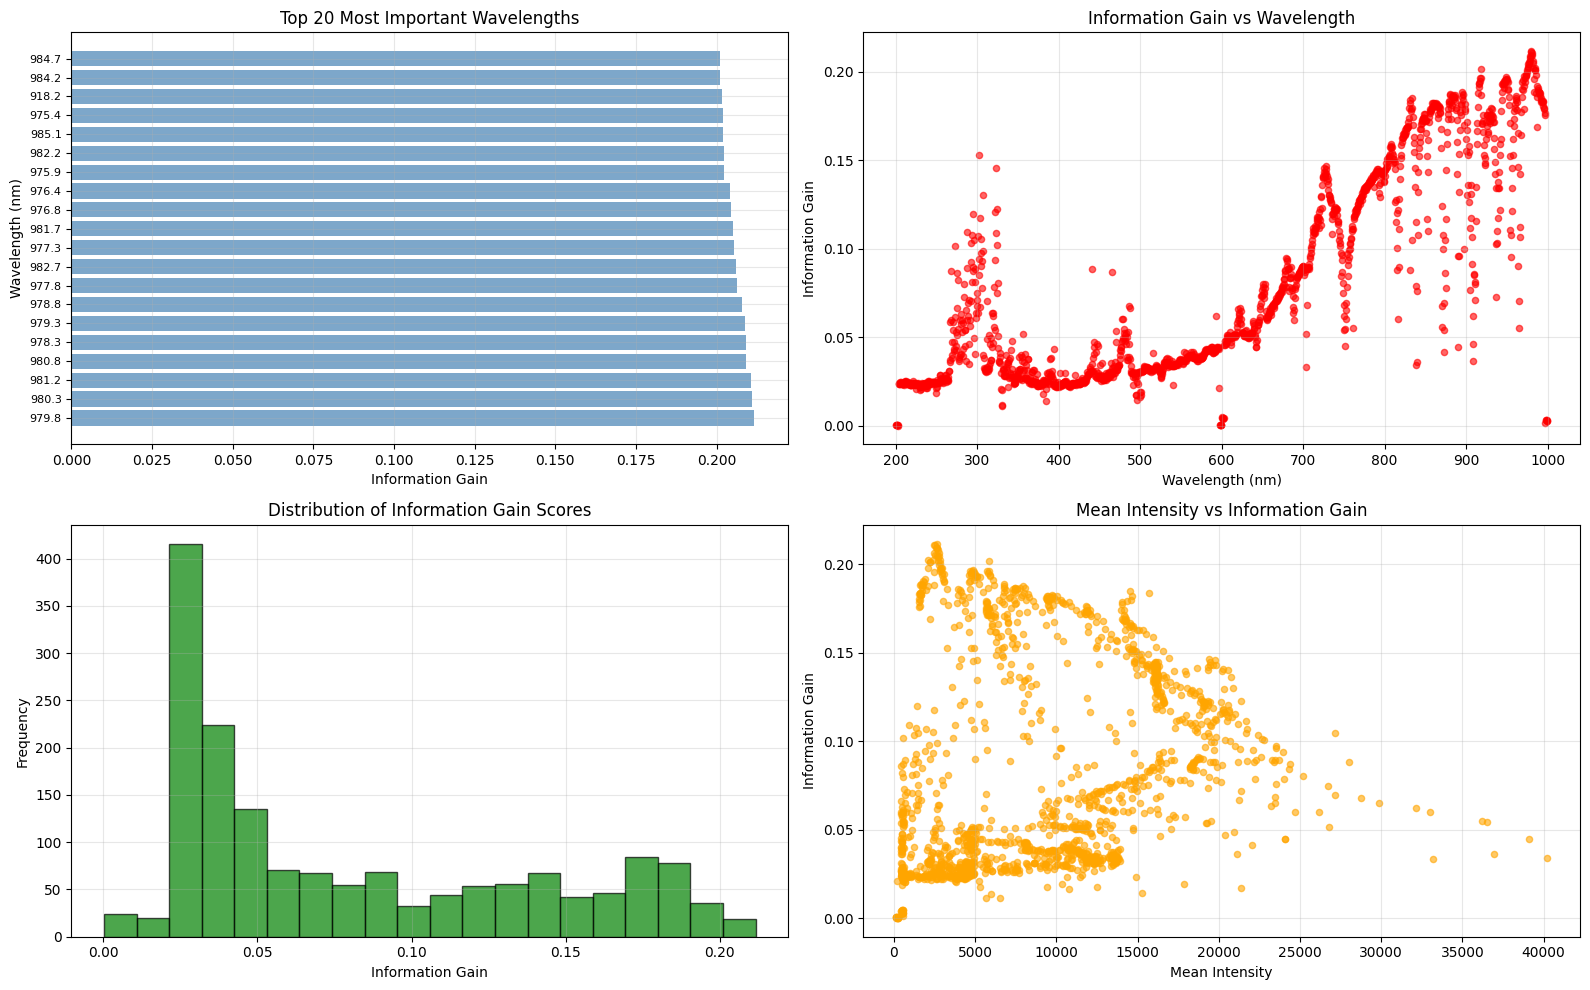


📊 WAVELENGTH IMPORTANCE SUMMARY
Metric                    Value          
----------------------------------------
Total wavelengths         1638           
Max information gain      0.2116         
Mean information gain     0.0799         
Std information gain      0.0582         

🔬 UV vs VIS Region Comparison:
UV region (< 400nm): 410 wavelengths, Mean IG: 0.0376
VIS region (≥ 400nm): 1228 wavelengths, Mean IG: 0.0940

🏆 TOP 10 MOST IMPORTANT WAVELENGTHS:
Rank  Wavelength   Info Gain    Mean Int    
--------------------------------------------------
1     979.8        0.2116       2643.87     
2     980.3        0.2109       2557.65     
3     981.2        0.2106       2464.77     
4     980.8        0.2093       2570.02     
5     978.3        0.2091       2647.60     
6     979.3        0.2089       2633.83     
7     978.8        0.2078       2707.48     
8     977.8        0.2063       2768.97     
9     982.7        0.2061       2460.40     
10    977.3        0.2054       267

In [49]:
# Visualize wavelength importance results
def visualize_wavelength_importance(importance_df, title_suffix=""):
    """Visualize wavelength importance results"""
    
    if len(importance_df) == 0:
        print("No data to visualize!")
        return
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    
    # 1. Top wavelengths bar plot
    top_20 = importance_df.head(20)
    
    axes[0, 0].barh(range(len(top_20)), top_20['information_gain'], 
                    color='steelblue', alpha=0.7)
    axes[0, 0].set_yticks(range(len(top_20)))
    axes[0, 0].set_yticklabels([f"{wl:.1f}" for wl in top_20['wavelength']], fontsize=8)
    axes[0, 0].set_xlabel('Information Gain')
    axes[0, 0].set_ylabel('Wavelength (nm)')
    axes[0, 0].set_title(f'Top 20 Most Important Wavelengths{title_suffix}')
    axes[0, 0].grid(True, alpha=0.3)
    
    # 2. Information gain vs wavelength scatter
    axes[0, 1].scatter(importance_df['wavelength'], importance_df['information_gain'], 
                       alpha=0.6, s=20, color='red')
    axes[0, 1].set_xlabel('Wavelength (nm)')
    axes[0, 1].set_ylabel('Information Gain')
    axes[0, 1].set_title(f'Information Gain vs Wavelength{title_suffix}')
    axes[0, 1].grid(True, alpha=0.3)
    
    # 3. Distribution of information gain scores
    axes[1, 0].hist(importance_df['information_gain'], bins=20, 
                    alpha=0.7, color='green', edgecolor='black')
    axes[1, 0].set_xlabel('Information Gain')
    axes[1, 0].set_ylabel('Frequency')
    axes[1, 0].set_title(f'Distribution of Information Gain Scores{title_suffix}')
    axes[1, 0].grid(True, alpha=0.3)
    
    # 4. Intensity mean vs information gain
    axes[1, 1].scatter(importance_df['intensity_mean'], importance_df['information_gain'], 
                       alpha=0.6, s=20, color='orange')
    axes[1, 1].set_xlabel('Mean Intensity')
    axes[1, 1].set_ylabel('Information Gain')
    axes[1, 1].set_title(f'Mean Intensity vs Information Gain{title_suffix}')
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Create visualization
visualize_wavelength_importance(importance_results)

# Print summary statistics
print(f"\n📊 WAVELENGTH IMPORTANCE SUMMARY")
print(f"{'Metric':<25} {'Value':<15}")
print("-" * 40)
print(f"{'Total wavelengths':<25} {len(importance_results):<15}")
print(f"{'Max information gain':<25} {importance_results['information_gain'].max():<15.4f}")
print(f"{'Mean information gain':<25} {importance_results['information_gain'].mean():<15.4f}")
print(f"{'Std information gain':<25} {importance_results['information_gain'].std():<15.4f}")

# UV vs VIS region analysis
uv_wavelengths = importance_results[importance_results['wavelength'] < 400]
vis_wavelengths = importance_results[importance_results['wavelength'] >= 400]

if len(uv_wavelengths) > 0 and len(vis_wavelengths) > 0:
    print(f"\n🔬 UV vs VIS Region Comparison:")
    print(f"UV region (< 400nm): {len(uv_wavelengths)} wavelengths, Mean IG: {uv_wavelengths['information_gain'].mean():.4f}")
    print(f"VIS region (≥ 400nm): {len(vis_wavelengths)} wavelengths, Mean IG: {vis_wavelengths['information_gain'].mean():.4f}")

# Top 10 most important wavelengths
print(f"\n🏆 TOP 10 MOST IMPORTANT WAVELENGTHS:")
print(f"{'Rank':<5} {'Wavelength':<12} {'Info Gain':<12} {'Mean Int':<12}")
print("-" * 50)

for i, (_, row) in enumerate(importance_results.head(10).iterrows(), 1):
    print(f"{i:<5} {row['wavelength']:<12.1f} {row['information_gain']:<12.4f} {row['intensity_mean']:<12.2f}")


🎯 Creating detailed visualization for top 20 wavelengths...


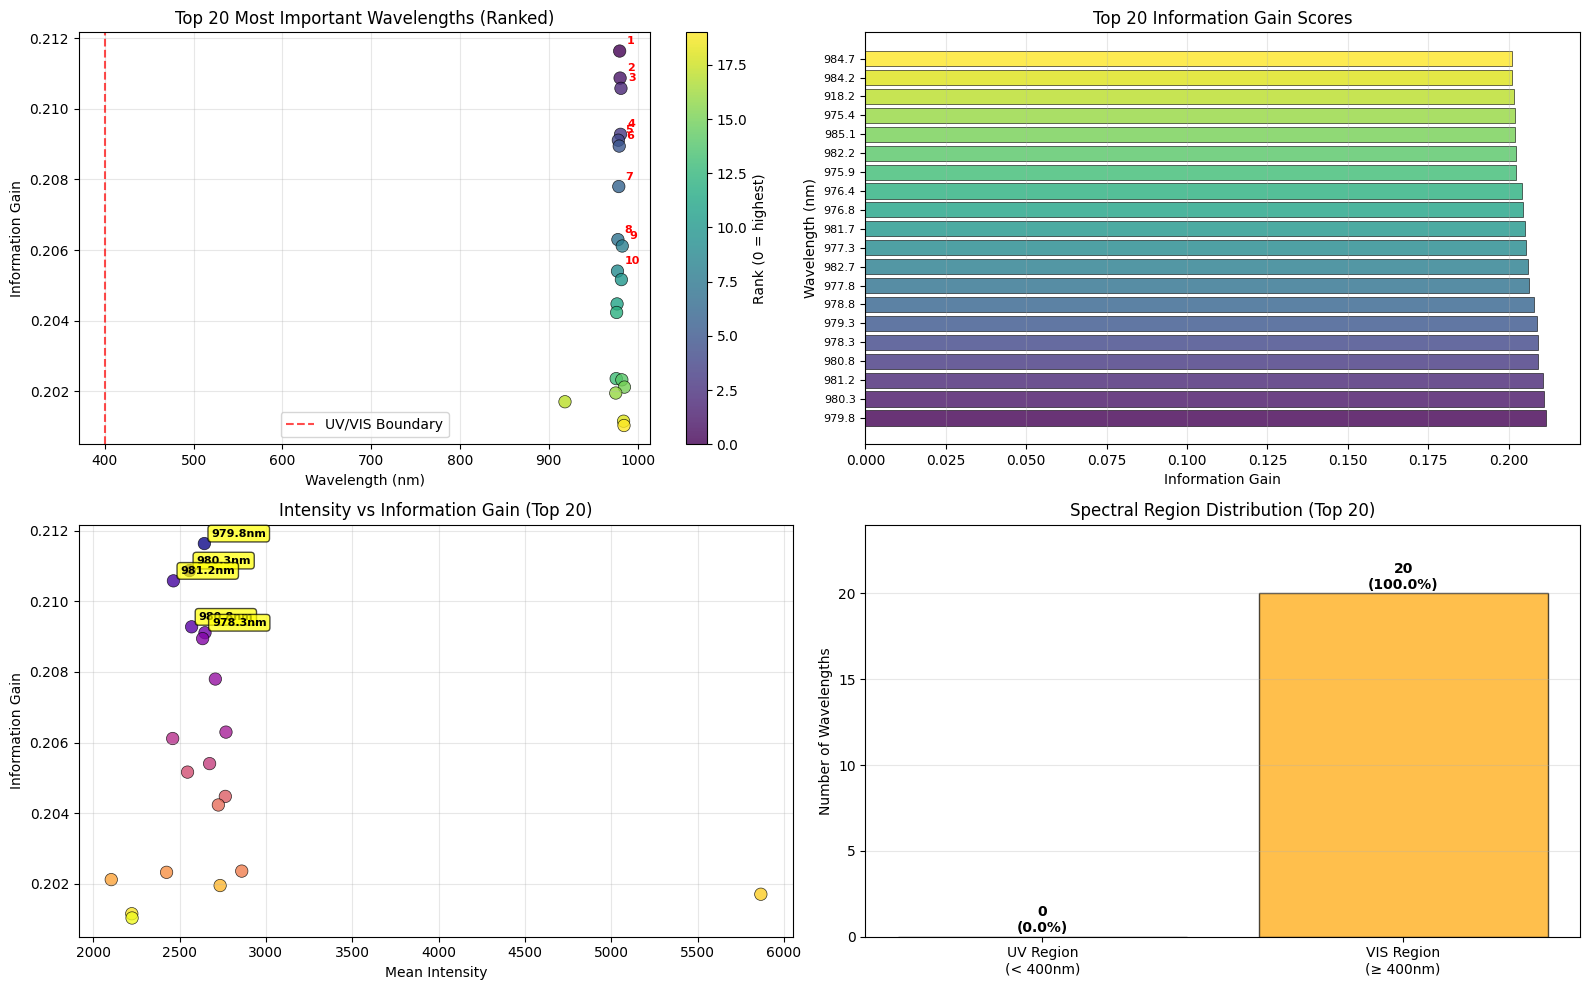


🔍 DETAILED ANALYSIS OF TOP 20 WAVELENGTHS:

📊 Regional Distribution:
UV region (< 400nm): 0 wavelengths (0.0%)
VIS region (≥ 400nm): 20 wavelengths (100.0%)

VIS wavelengths: [918.212, 975.376, 975.864, 976.353, 976.841, 977.33, 977.818, 978.307, 978.796, 979.284, 979.773, 980.261, 980.75, 981.239, 981.727, 982.216, 982.704, 984.17, 984.659, 985.147]
Mean VIS Information Gain: 0.2056

📈 Statistical Summary of Top 20:
Information Gain range: 0.2010 - 0.2116
Mean Information Gain: 0.2056
Wavelength range: 918.2 - 985.1 nm
Mean Intensity range: 2104.8 - 5865.7


In [50]:
# Add this new plot after the existing visualize_wavelength_importance function call

def visualize_top_wavelengths_detailed(importance_df, top_n=20):
    """Create detailed visualization focusing on top N wavelengths"""
    
    if len(importance_df) == 0:
        print("No data to visualize!")
        return
    
    # Get top N wavelengths
    top_wavelengths = importance_df.head(top_n)
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    
    # 1. Top N wavelengths scatter plot with annotations
    scatter = axes[0, 0].scatter(top_wavelengths['wavelength'], 
                                top_wavelengths['information_gain'], 
                                alpha=0.8, s=80, c=range(len(top_wavelengths)), 
                                cmap='viridis', edgecolor='black', linewidth=0.5)
    
    # Add rank annotations for top 10
    for i, (_, row) in enumerate(top_wavelengths.head(10).iterrows()):
        axes[0, 0].annotate(f'{i+1}', 
                           (row['wavelength'], row['information_gain']),
                           xytext=(5, 5), textcoords='offset points',
                           fontsize=8, fontweight='bold', color='red')
    
    axes[0, 0].set_xlabel('Wavelength (nm)')
    axes[0, 0].set_ylabel('Information Gain')
    axes[0, 0].set_title(f'Top {top_n} Most Important Wavelengths (Ranked)')
    axes[0, 0].grid(True, alpha=0.3)
    
    # Add colorbar
    cbar = plt.colorbar(scatter, ax=axes[0, 0])
    cbar.set_label('Rank (0 = highest)')
    
    # Add UV/VIS boundary line
    axes[0, 0].axvline(x=400, color='red', linestyle='--', alpha=0.7, label='UV/VIS Boundary')
    axes[0, 0].legend()
    
    # 2. Information gain values as bar plot (top 20)
    y_pos = np.arange(len(top_wavelengths))
    bars = axes[0, 1].barh(y_pos, top_wavelengths['information_gain'], 
                          color=plt.cm.viridis(np.linspace(0, 1, len(top_wavelengths))),
                          alpha=0.8, edgecolor='black', linewidth=0.5)
    
    axes[0, 1].set_yticks(y_pos)
    axes[0, 1].set_yticklabels([f"{wl:.1f}" for wl in top_wavelengths['wavelength']], fontsize=8)
    axes[0, 1].set_xlabel('Information Gain')
    axes[0, 1].set_ylabel('Wavelength (nm)')
    axes[0, 1].set_title(f'Top {top_n} Information Gain Scores')
    axes[0, 1].grid(True, alpha=0.3, axis='x')
    
    # 3. Intensity vs Information Gain for top wavelengths
    scatter2 = axes[1, 0].scatter(top_wavelengths['intensity_mean'], 
                                 top_wavelengths['information_gain'],
                                 alpha=0.8, s=80, c=range(len(top_wavelengths)), 
                                 cmap='plasma', edgecolor='black', linewidth=0.5)
    
    # Annotate top 5
    for i, (_, row) in enumerate(top_wavelengths.head(5).iterrows()):
        axes[1, 0].annotate(f'{row["wavelength"]:.1f}nm', 
                           (row['intensity_mean'], row['information_gain']),
                           xytext=(5, 5), textcoords='offset points',
                           fontsize=8, fontweight='bold', 
                           bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.7))
    
    axes[1, 0].set_xlabel('Mean Intensity')
    axes[1, 0].set_ylabel('Information Gain')
    axes[1, 0].set_title(f'Intensity vs Information Gain (Top {top_n})')
    axes[1, 0].grid(True, alpha=0.3)
    
    # 4. Wavelength distribution analysis (UV vs VIS)
    uv_wavelengths = top_wavelengths[top_wavelengths['wavelength'] < 400]
    vis_wavelengths = top_wavelengths[top_wavelengths['wavelength'] >= 400]
    
    categories = ['UV Region\n(< 400nm)', 'VIS Region\n(≥ 400nm)']
    counts = [len(uv_wavelengths), len(vis_wavelengths)]
    colors = ['purple', 'orange']
    
    bars = axes[1, 1].bar(categories, counts, color=colors, alpha=0.7, 
                         edgecolor='black', linewidth=1)
    
    # Add count labels on bars
    for bar, count in zip(bars, counts):
        height = bar.get_height()
        axes[1, 1].text(bar.get_x() + bar.get_width()/2., height + 0.1,
                        f'{count}\n({count/top_n*100:.1f}%)',
                        ha='center', va='bottom', fontweight='bold')
    
    axes[1, 1].set_ylabel('Number of Wavelengths')
    axes[1, 1].set_title(f'Spectral Region Distribution (Top {top_n})')
    axes[1, 1].grid(True, alpha=0.3, axis='y')
    axes[1, 1].set_ylim(0, max(counts) * 1.2)
    
    plt.tight_layout()
    plt.show()
    
    # Print detailed analysis
    print(f"\n🔍 DETAILED ANALYSIS OF TOP {top_n} WAVELENGTHS:")
    print("=" * 60)
    
    print(f"\n📊 Regional Distribution:")
    print(f"UV region (< 400nm): {len(uv_wavelengths)} wavelengths ({len(uv_wavelengths)/top_n*100:.1f}%)")
    print(f"VIS region (≥ 400nm): {len(vis_wavelengths)} wavelengths ({len(vis_wavelengths)/top_n*100:.1f}%)")
    
    if len(uv_wavelengths) > 0:
        print(f"\nUV wavelengths: {sorted(uv_wavelengths['wavelength'].tolist())}")
        print(f"Mean UV Information Gain: {uv_wavelengths['information_gain'].mean():.4f}")
    
    if len(vis_wavelengths) > 0:
        print(f"\nVIS wavelengths: {sorted(vis_wavelengths['wavelength'].tolist())}")
        print(f"Mean VIS Information Gain: {vis_wavelengths['information_gain'].mean():.4f}")
    
    print(f"\n📈 Statistical Summary of Top {top_n}:")
    print(f"Information Gain range: {top_wavelengths['information_gain'].min():.4f} - {top_wavelengths['information_gain'].max():.4f}")
    print(f"Mean Information Gain: {top_wavelengths['information_gain'].mean():.4f}")
    print(f"Wavelength range: {top_wavelengths['wavelength'].min():.1f} - {top_wavelengths['wavelength'].max():.1f} nm")
    print(f"Mean Intensity range: {top_wavelengths['intensity_mean'].min():.1f} - {top_wavelengths['intensity_mean'].max():.1f}")

# Create the detailed visualization for top 20 wavelengths
print("\n🎯 Creating detailed visualization for top 20 wavelengths...")
visualize_top_wavelengths_detailed(importance_results, top_n=20)

🧪 Performing PLS-DA Analysis on LIBS Data...
Using 51453 samples and 8188 wavelengths
🚀 Starting PLS-DA Analysis for LIBS Data
📊 Preparing data for PLS-DA...
Dataset shape: (5000, 819)
Classes: ['innerliner' 'sidewall' 'tread']
Class distribution: [1716 1525 1759]
Applying HYBRID baseline correction to 5000 spectra in batches of 100...
  Processing batch 1/50 (spectra 1-100)


  Processing batch 2/50 (spectra 101-200)
  Processing batch 3/50 (spectra 201-300)
  Processing batch 4/50 (spectra 301-400)
  Processing batch 5/50 (spectra 401-500)
  Processing batch 6/50 (spectra 501-600)
  Processing batch 7/50 (spectra 601-700)
  Processing batch 8/50 (spectra 701-800)
  Processing batch 9/50 (spectra 801-900)
  Processing batch 10/50 (spectra 901-1000)
  Processing batch 11/50 (spectra 1001-1100)
  Processing batch 12/50 (spectra 1101-1200)
  Processing batch 13/50 (spectra 1201-1300)
  Processing batch 14/50 (spectra 1301-1400)
  Processing batch 15/50 (spectra 1401-1500)
  Processing batch 16/50 (spectra 1501-1600)
  Processing batch 17/50 (spectra 1601-1700)
  Processing batch 18/50 (spectra 1701-1800)
  Processing batch 19/50 (spectra 1801-1900)
  Processing batch 20/50 (spectra 1901-2000)
  Processing batch 21/50 (spectra 2001-2100)
  Processing batch 22/50 (spectra 2101-2200)
  Processing batch 23/50 (spectra 2201-2300)
  Processing batch 24/50 (spectra 2

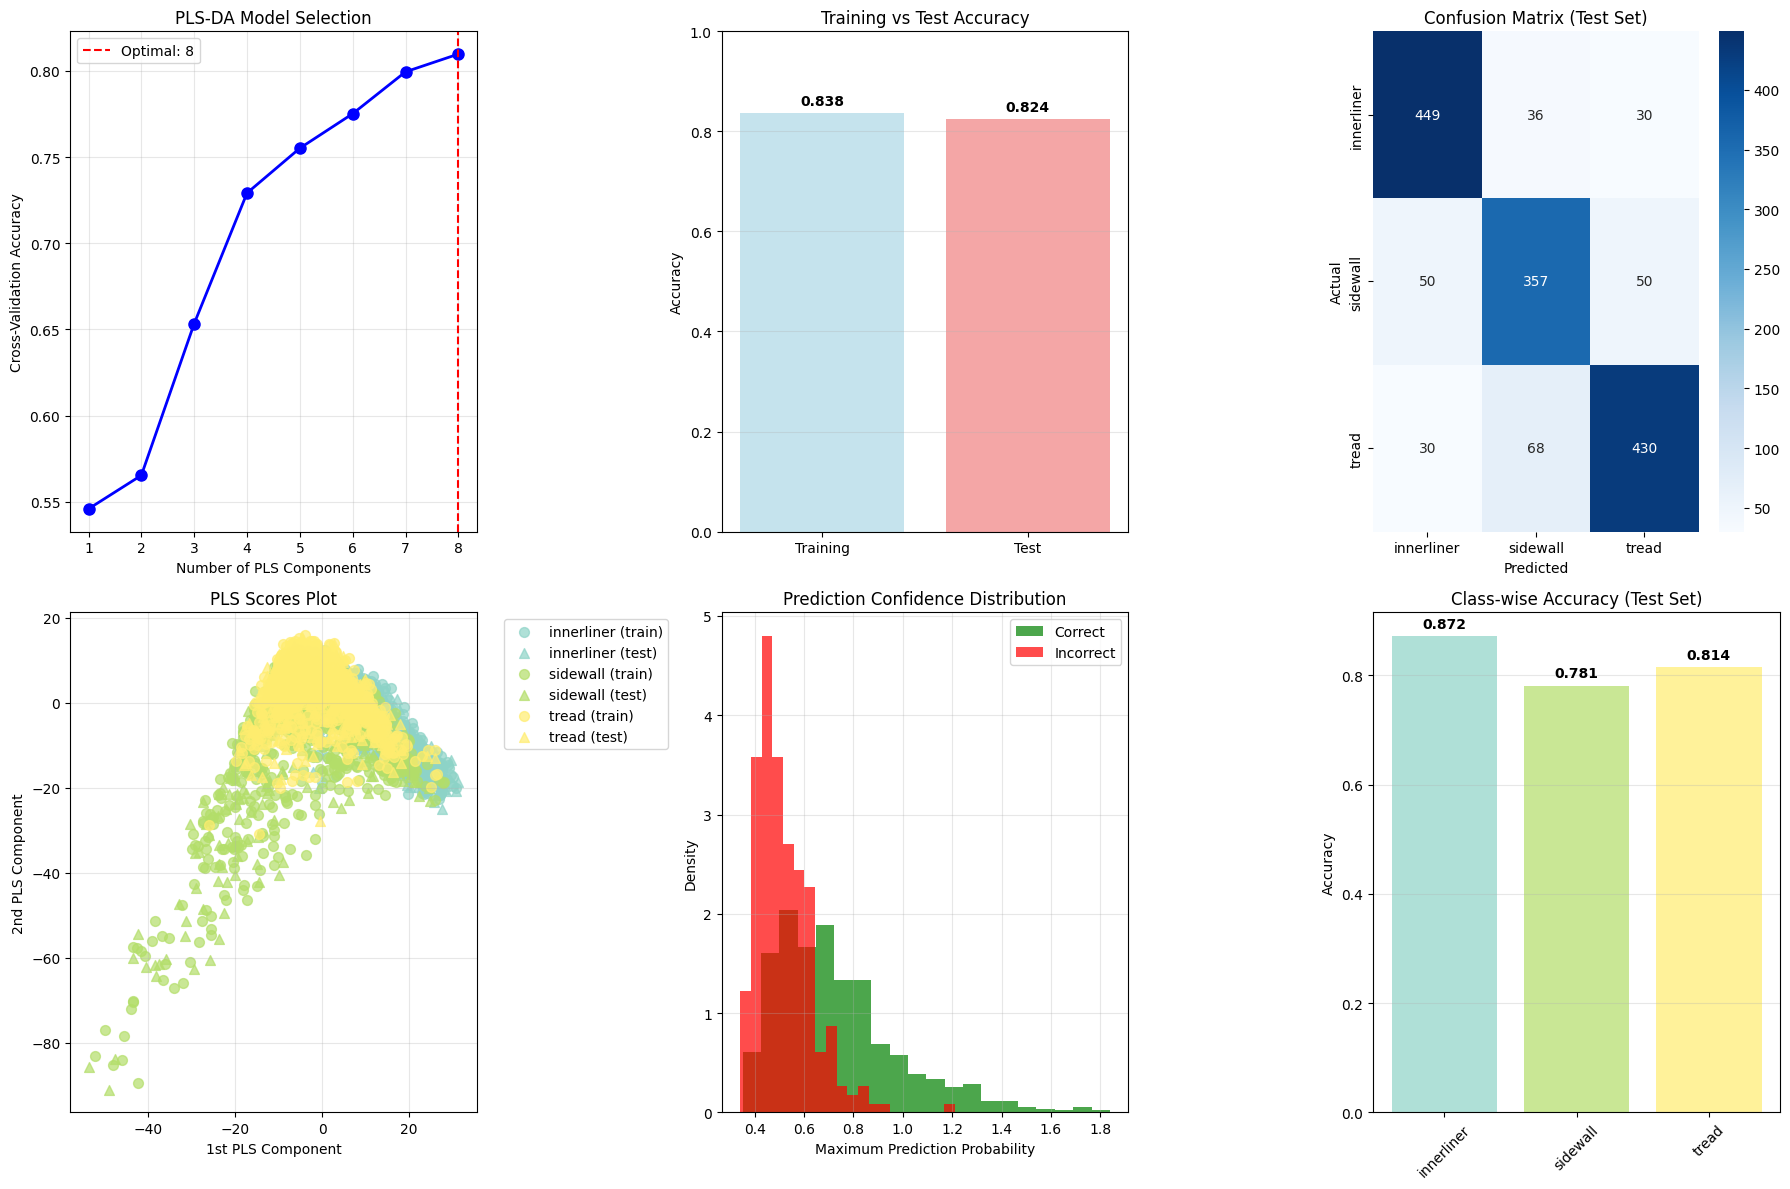


🔍 Analyzing PLS-DA Variable Importance...


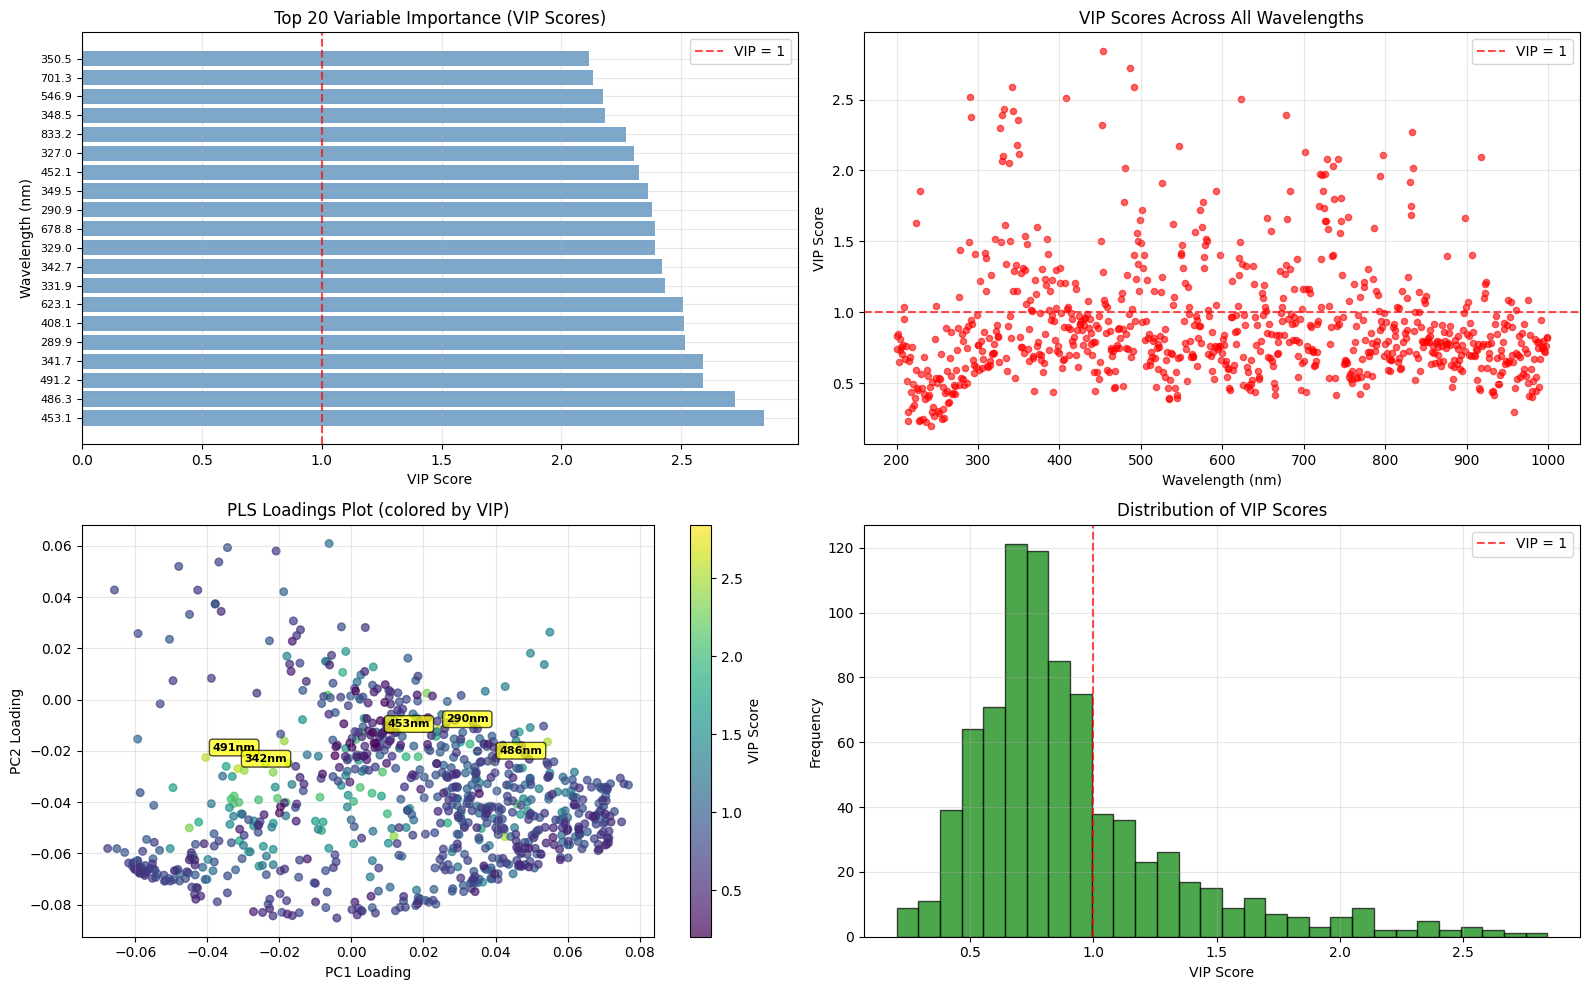


📊 PLS-DA VARIABLE IMPORTANCE SUMMARY
Metric                         Value          
---------------------------------------------
Total variables                819            
Variables with VIP > 1         220            
Max VIP score                  2.8424         
Mean VIP score                 0.9062         

🏆 TOP 20 MOST IMPORTANT WAVELENGTHS (VIP > 1):
Rank  Wavelength   VIP Score   
-----------------------------------
1     453.1        2.8424      
2     486.3        2.7252      
3     491.2        2.5916      
4     341.7        2.5896      
5     289.9        2.5152      
6     408.1        2.5122      
7     623.1        2.5047      
8     331.9        2.4328      
9     342.7        2.4206      
10    329.0        2.3916      
11    678.8        2.3911      
12    290.9        2.3754      
13    349.5        2.3590      
14    452.1        2.3219      
15    327.0        2.3011      
16    833.2        2.2693      
17    348.5        2.1794      
18    546.9        2.

NameError: name 'importance_df' is not defined

In [ ]:
# Section 11: PLS-DA Feature Selection and Classification

from sklearn.cross_decomposition import PLSRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def perform_plsda_analysis(df, wavelength_columns, n_components_range=(1, 8), test_size=0.3, random_state=42):
    """
    Comprehensive PLS-DA analysis for LIBS spectral data
    """
    
    print("🚀 Starting PLS-DA Analysis for LIBS Data")
    print("=" * 60)
    
    # 1. Prepare the data
    print("📊 Preparing data for PLS-DA...")
    
    # Get features (wavelength intensities) and target (origin)
    X = df[wavelength_columns].values
    y = df['origin'].values
    
    # Encode target labels
    label_encoder = LabelEncoder()
    y_encoded = label_encoder.fit_transform(y)
    
    print(f"Dataset shape: {X.shape}")
    print(f"Classes: {label_encoder.classes_}")
    print(f"Class distribution: {np.bincount(y_encoded)}")
    
    X_corrected = baseline_corrector.apply_correction_batch(X)

    # 2. Standardize features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_corrected)

    # 3. Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y_encoded, test_size=test_size, 
        random_state=random_state, stratify=y_encoded
    )
    
    print(f"Training set: {X_train.shape}")
    print(f"Test set: {X_test.shape}")
    
    # 4. Find optimal number of components
    print(f"\n🔍 Finding optimal number of PLS components...")
    
    cv_scores = []
    n_components_list = list(range(n_components_range[0], n_components_range[1] + 1))
    
    # Use StratifiedKFold for cross-validation
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)
    
    for n_comp in n_components_list:
        # Create dummy target matrix for PLS (one-hot encoded)
        Y_train_dummy = np.zeros((len(y_train), len(label_encoder.classes_)))
        for i, class_idx in enumerate(y_train):
            Y_train_dummy[i, class_idx] = 1
        
        # Fit PLS model
        pls = PLSRegression(n_components=n_comp)
        
        # Cross-validation scores
        scores = []
        for train_idx, val_idx in cv.split(X_train, y_train):
            X_train_fold, X_val_fold = X_train[train_idx], X_train[val_idx]
            Y_train_fold, y_val_fold = Y_train_dummy[train_idx], y_train[val_idx]
            
            # Fit and predict
            pls.fit(X_train_fold, Y_train_fold)
            Y_pred = pls.predict(X_val_fold)
            
            # Convert predictions back to class labels
            y_pred_fold = np.argmax(Y_pred, axis=1)
            scores.append(accuracy_score(y_val_fold, y_pred_fold))
        
        cv_scores.append(np.mean(scores))
        print(f"Components: {n_comp:2d}, CV Accuracy: {np.mean(scores):.4f} ± {np.std(scores):.4f}")
    
    # Find optimal number of components
    optimal_n_comp = n_components_list[np.argmax(cv_scores)]
    print(f"\n✅ Optimal number of components: {optimal_n_comp}")
    print(f"Best CV accuracy: {max(cv_scores):.4f}")
    
    # 5. Train final model with optimal components
    print(f"\n🎯 Training final PLS-DA model with {optimal_n_comp} components...")
    
    # Create dummy target matrix
    Y_train_dummy = np.zeros((len(y_train), len(label_encoder.classes_)))
    for i, class_idx in enumerate(y_train):
        Y_train_dummy[i, class_idx] = 1
    
    Y_test_dummy = np.zeros((len(y_test), len(label_encoder.classes_)))
    for i, class_idx in enumerate(y_test):
        Y_test_dummy[i, class_idx] = 1
    
    # Final PLS model
    final_pls = PLSRegression(n_components=optimal_n_comp)
    final_pls.fit(X_train, Y_train_dummy)
    
    # 6. Make predictions
    Y_train_pred = final_pls.predict(X_train)
    Y_test_pred = final_pls.predict(X_test)
    
    # Convert predictions to class labels
    y_train_pred = np.argmax(Y_train_pred, axis=1)
    y_test_pred = np.argmax(Y_test_pred, axis=1)
    
    # 7. Evaluate model
    train_accuracy = accuracy_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)
    
    print(f"\n📈 Model Performance:")
    print(f"Training Accuracy: {train_accuracy:.4f}")
    print(f"Test Accuracy: {test_accuracy:.4f}")
    
    # 8. Create visualizations
    create_plsda_visualizations(
        final_pls, X_train, X_test, y_train, y_test, 
        y_train_pred, y_test_pred, Y_train_pred, Y_test_pred,
        label_encoder, cv_scores, n_components_list, optimal_n_comp
    )
    
    # 9. Variable importance analysis
    variable_importance = analyze_plsda_variable_importance(
        final_pls, wavelength_columns, optimal_n_comp
    )
    
    return {
        'model': final_pls,
        'scaler': scaler,
        'label_encoder': label_encoder,
        'optimal_n_components': optimal_n_comp,
        'cv_scores': cv_scores,
        'train_accuracy': train_accuracy,
        'test_accuracy': test_accuracy,
        'variable_importance': variable_importance,
        'X_train': X_train,
        'X_test': X_test,
        'y_train': y_train,
        'y_test': y_test,
        'y_train_pred': y_train_pred,
        'y_test_pred': y_test_pred
    }

def create_plsda_visualizations(pls_model, X_train, X_test, y_train, y_test, 
                               y_train_pred, y_test_pred, Y_train_pred, Y_test_pred,
                               label_encoder, cv_scores, n_components_list, optimal_n_comp):
    """Create comprehensive PLS-DA visualizations"""
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    # 1. Cross-validation scores
    axes[0, 0].plot(n_components_list, cv_scores, 'bo-', linewidth=2, markersize=8)
    axes[0, 0].axvline(x=optimal_n_comp, color='red', linestyle='--', 
                      label=f'Optimal: {optimal_n_comp}')
    axes[0, 0].set_xlabel('Number of PLS Components')
    axes[0, 0].set_ylabel('Cross-Validation Accuracy')
    axes[0, 0].set_title('PLS-DA Model Selection')
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].legend()
    
    # 2. Training vs Test Accuracy Comparison
    accuracies = ['Training', 'Test']
    scores = [accuracy_score(y_train, y_train_pred), accuracy_score(y_test, y_test_pred)]
    
    bars = axes[0, 1].bar(accuracies, scores, color=['lightblue', 'lightcoral'], alpha=0.7)
    axes[0, 1].set_ylabel('Accuracy')
    axes[0, 1].set_title('Training vs Test Accuracy')
    axes[0, 1].set_ylim(0, 1)
    
    # Add value labels on bars
    for bar, score in zip(bars, scores):
        height = bar.get_height()
        axes[0, 1].text(bar.get_x() + bar.get_width()/2., height + 0.01,
                       f'{score:.3f}', ha='center', va='bottom', fontweight='bold')
    
    axes[0, 1].grid(True, alpha=0.3, axis='y')
    
    # 3. Confusion Matrix
    cm = confusion_matrix(y_test, y_test_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=label_encoder.classes_,
                yticklabels=label_encoder.classes_,
                ax=axes[0, 2])
    axes[0, 2].set_title('Confusion Matrix (Test Set)')
    axes[0, 2].set_xlabel('Predicted')
    axes[0, 2].set_ylabel('Actual')
    
    # 4. PLS Scores Plot (first two components)
    if pls_model.n_components >= 2:
        # Get PLS scores for training data
        T_train = pls_model.transform(X_train)
        T_test = pls_model.transform(X_test)
        
        # Create color map for classes
        colors = plt.cm.Set3(np.linspace(0, 1, len(label_encoder.classes_)))
        
        for i, class_name in enumerate(label_encoder.classes_):
            train_mask = y_train == i
            test_mask = y_test == i
            
            axes[1, 0].scatter(T_train[train_mask, 0], T_train[train_mask, 1], 
                             c=[colors[i]], label=f'{class_name} (train)', 
                             alpha=0.7, s=50, marker='o')
            axes[1, 0].scatter(T_test[test_mask, 0], T_test[test_mask, 1], 
                             c=[colors[i]], label=f'{class_name} (test)', 
                             alpha=0.7, s=50, marker='^')
        
        axes[1, 0].set_xlabel('1st PLS Component')
        axes[1, 0].set_ylabel('2nd PLS Component')
        axes[1, 0].set_title('PLS Scores Plot')
        axes[1, 0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        axes[1, 0].grid(True, alpha=0.3)
    else:
        axes[1, 0].text(0.5, 0.5, 'Need ≥2 components\nfor scores plot', 
                       ha='center', va='center', transform=axes[1, 0].transAxes)
        axes[1, 0].set_title('PLS Scores Plot')
    
    # 5. Prediction Confidence
    max_probs_test = np.max(Y_test_pred, axis=1)
    correct_predictions = (y_test == y_test_pred)
    
    axes[1, 1].hist(max_probs_test[correct_predictions], bins=20, alpha=0.7, 
                   label='Correct', color='green', density=True)
    axes[1, 1].hist(max_probs_test[~correct_predictions], bins=20, alpha=0.7, 
                   label='Incorrect', color='red', density=True)
    axes[1, 1].set_xlabel('Maximum Prediction Probability')
    axes[1, 1].set_ylabel('Density')
    axes[1, 1].set_title('Prediction Confidence Distribution')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    # 6. Class-wise Performance
    class_accuracies = []
    for i, class_name in enumerate(label_encoder.classes_):
        class_mask = y_test == i
        if np.sum(class_mask) > 0:
            class_acc = accuracy_score(y_test[class_mask], y_test_pred[class_mask])
            class_accuracies.append(class_acc)
        else:
            class_accuracies.append(0)
    
    bars = axes[1, 2].bar(label_encoder.classes_, class_accuracies, 
                         color=colors[:len(label_encoder.classes_)], alpha=0.7)
    axes[1, 2].set_ylabel('Accuracy')
    axes[1, 2].set_title('Class-wise Accuracy (Test Set)')
    axes[1, 2].tick_params(axis='x', rotation=45)
    
    # Add value labels
    for bar, acc in zip(bars, class_accuracies):
        height = bar.get_height()
        axes[1, 2].text(bar.get_x() + bar.get_width()/2., height + 0.01,
                       f'{acc:.3f}', ha='center', va='bottom', fontweight='bold')
    
    axes[1, 2].grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()

def analyze_plsda_variable_importance(pls_model, wavelength_columns, n_components, top_n=20):
    """Analyze variable importance in PLS-DA model"""
    
    print(f"\n🔍 Analyzing PLS-DA Variable Importance...")
    
    # Calculate Variable Importance in Projection (VIP) scores
    W = pls_model.x_weights_  # X weights
    P = pls_model.x_loadings_  # X loadings
    Q = pls_model.y_loadings_  # Y loadings
    
    # Calculate VIP scores
    n_vars = W.shape[0]
    vip_scores = np.zeros(n_vars)
    
    # Sum of squares of Y loadings for each component
    ss_y = np.sum(Q**2, axis=0)
    
    for i in range(n_vars):
        weight_sum = 0
        for j in range(n_components):
            weight_sum += (W[i, j] / np.linalg.norm(W[:, j]))**2 * ss_y[j]
        vip_scores[i] = np.sqrt(n_vars * weight_sum / np.sum(ss_y))
    
    # Create importance DataFrame
    importance_df = pd.DataFrame({
        'wavelength': [float(col) for col in wavelength_columns],
        'vip_score': vip_scores,
        'loading_pc1': P[:, 0] if n_components >= 1 else np.zeros(n_vars),
        'loading_pc2': P[:, 1] if n_components >= 2 else np.zeros(n_vars),
        'weight_pc1': W[:, 0] if n_components >= 1 else np.zeros(n_vars),
        'weight_pc2': W[:, 1] if n_components >= 2 else np.zeros(n_vars)
    })
    
    # Sort by VIP score
    importance_df = importance_df.sort_values('vip_score', ascending=False)
    
    # Visualize variable importance
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    
    # 1. Top VIP scores
    top_vip = importance_df.head(top_n)
    
    axes[0, 0].barh(range(len(top_vip)), top_vip['vip_score'], 
                    color='steelblue', alpha=0.7)
    axes[0, 0].set_yticks(range(len(top_vip)))
    axes[0, 0].set_yticklabels([f"{wl:.1f}" for wl in top_vip['wavelength']], fontsize=8)
    axes[0, 0].set_xlabel('VIP Score')
    axes[0, 0].set_ylabel('Wavelength (nm)')
    axes[0, 0].set_title(f'Top {top_n} Variable Importance (VIP Scores)')
    axes[0, 0].axvline(x=1, color='red', linestyle='--', alpha=0.7, label='VIP = 1')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # 2. VIP scores vs wavelength
    axes[0, 1].scatter(importance_df['wavelength'], importance_df['vip_score'], 
                       alpha=0.6, s=20, color='red')
    axes[0, 1].axhline(y=1, color='red', linestyle='--', alpha=0.7, label='VIP = 1')
    axes[0, 1].set_xlabel('Wavelength (nm)')
    axes[0, 1].set_ylabel('VIP Score')
    axes[0, 1].set_title('VIP Scores Across All Wavelengths')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # 3. Loadings plot (PC1 vs PC2)
    if n_components >= 2:
        scatter = axes[1, 0].scatter(importance_df['loading_pc1'], 
                                   importance_df['loading_pc2'],
                                   c=importance_df['vip_score'], 
                                   cmap='viridis', alpha=0.7, s=30)
        
        # Annotate top VIP variables
        for _, row in top_vip.head(5).iterrows():
            axes[1, 0].annotate(f'{row["wavelength"]:.0f}nm', 
                               (row['loading_pc1'], row['loading_pc2']),
                               xytext=(5, 5), textcoords='offset points',
                               fontsize=8, fontweight='bold',
                               bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.7))
        
        axes[1, 0].set_xlabel('PC1 Loading')
        axes[1, 0].set_ylabel('PC2 Loading')
        axes[1, 0].set_title('PLS Loadings Plot (colored by VIP)')
        axes[1, 0].grid(True, alpha=0.3)
        
        # Add colorbar
        cbar = plt.colorbar(scatter, ax=axes[1, 0])
        cbar.set_label('VIP Score')
    else:
        axes[1, 0].text(0.5, 0.5, 'Need ≥2 components\nfor loadings plot', 
                       ha='center', va='center', transform=axes[1, 0].transAxes)
        axes[1, 0].set_title('PLS Loadings Plot')
    
    # 4. VIP score distribution
    axes[1, 1].hist(importance_df['vip_score'], bins=30, alpha=0.7, 
                   color='green', edgecolor='black')
    axes[1, 1].axvline(x=1, color='red', linestyle='--', alpha=0.7, label='VIP = 1')
    axes[1, 1].set_xlabel('VIP Score')
    axes[1, 1].set_ylabel('Frequency')
    axes[1, 1].set_title('Distribution of VIP Scores')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print summary
    print(f"\n📊 PLS-DA VARIABLE IMPORTANCE SUMMARY")
    print(f"{'Metric':<30} {'Value':<15}")
    print("-" * 45)
    print(f"{'Total variables':<30} {len(importance_df):<15}")
    print(f"{'Variables with VIP > 1':<30} {np.sum(importance_df['vip_score'] > 1):<15}")
    print(f"{'Max VIP score':<30} {importance_df['vip_score'].max():<15.4f}")
    print(f"{'Mean VIP score':<30} {importance_df['vip_score'].mean():<15.4f}")
    
    # Top wavelengths
    print(f"\n🏆 TOP {top_n} MOST IMPORTANT WAVELENGTHS (VIP > 1):")
    print(f"{'Rank':<5} {'Wavelength':<12} {'VIP Score':<12}")
    print("-" * 35)
    
    important_vars = importance_df[importance_df['vip_score'] > 1].head(top_n)
    for i, (_, row) in enumerate(important_vars.iterrows(), 1):
        print(f"{i:<5} {row['wavelength']:<12.1f} {row['vip_score']:<12.4f}")
    
    return importance_df

# Run PLS-DA Analysis
print("🧪 Performing PLS-DA Analysis on LIBS Data...")

# Use a sample of the data for performance (adjust as needed)
sample_size = 5000  # Adjust based on your computational resources
df_sample = df.sample(n=min(sample_size, len(df)), random_state=42)

# Use every 10th wavelength for faster computation (adjust as needed)
wavelength_subset = wavelength_columns[::10]  # Every 10th wavelength

print(f"Using {len(df)} samples and {len(wavelength_columns)} wavelengths")

# Perform PLS-DA analysis
plsda_results = perform_plsda_analysis(
    df_sample, 
    wavelength_subset, 
    n_components_range=(1, 8),
    test_size=0.3,
    random_state=42
)

print("\n🎉 PLS-DA ANALYSIS COMPLETED!")
print("=" * 50)
print(f"✅ Optimal components: {plsda_results['optimal_n_components']}")
print(f"✅ Test accuracy: {plsda_results['test_accuracy']:.4f}")
print(f"✅ Variables with VIP > 1: {np.sum(plsda_results['variable_importance']['vip_score'] > 1)}")

In [3]:
df = pd.read_csv('data/csv/processed_data.csv')

In [31]:
nist_df = pd.read_csv('data/csv/nist_data.csv')

In [ ]:
nist_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24846 entries, 0 to 24845
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   element         24846 non-null  object 
 1   sp_num          24846 non-null  int64  
 2   obs_wl_air(nm)  24846 non-null  object 
 3   intens          24846 non-null  object 
 4   Aki(s^-1)       24846 non-null  object 
 5   Acc             11738 non-null  object 
 6   conf_i          24846 non-null  object 
 7   conf_k          24846 non-null  object 
 8   Type            0 non-null      float64
 9   tp_ref          24846 non-null  object 
 10  line_ref        24846 non-null  object 
 11  Column1         0 non-null      float64
dtypes: float64(2), int64(1), object(9)
memory usage: 2.3+ MB


In [28]:
nist_df.head()

,element,sp_num,obs_wl_air(nm),intens,Aki(s^-1),Acc,conf_i,conf_k,Type,tp_ref,line_ref,Column1
0,Fe,3,NaN,"=""44000""","=""2.3e+08""",C,"=""3d5.(a 2G).4s""","=""3d5.(4F).4p""",NaN,"=""u45""","=""L11223""",NaN
1,Fe,3,NaN,"=""2200""","=""""",NaN,"=""3d5.(4F).4s""","=""3d5.(a 2F).4p""",NaN,"=""""","=""L11223""",NaN
2,Fe,2,NaN,"=""80000""","=""9.5e+07""",C+,"=""3d7""","=""3d6.(3G).4p""",NaN,"=""T6892c83""","=""L18349c139""",NaN
3,S,2,NaN,"=""5800""","=""""",NaN,"=""3s2.3p2.(3P).3d""","=""3s2.3p2.(3P<1>).4f""",NaN,"=""""","=""L5883""",NaN
4,Mn,2,NaN,"=""80""","=""""",NaN,"=""3d6""","=""3d5.(2D).4p""",NaN,"=""""","=""L562""",NaN


In [32]:
# Clean the wavelength column by removing quotes and equal signs
print("Before cleaning:")
print(nist_df['obs_wl_air(nm)'].head())

# Method 1: Remove quotes and equal signs, then convert
nist_df['obs_wl_air(nm)'] = nist_df['obs_wl_air(nm)'].astype(str).str.replace('"', '', regex=False)
nist_df['obs_wl_air(nm)'] = nist_df['obs_wl_air(nm)'].str.replace('=', '', regex=False)

print("After removing quotes and equal signs:")
print(nist_df['obs_wl_air(nm)'].head())

# Now convert to numeric
nist_df['obs_wl_air(nm)'] = pd.to_numeric(nist_df['obs_wl_air(nm)'], errors='coerce')

print("After converting to numeric:")
print(nist_df['obs_wl_air(nm)'].head())
print("Number of NaN values:", nist_df['obs_wl_air(nm)'].isna().sum())
nist_df.head()

Before cleaning:
0      ="200.0046"
1      ="200.0148"
2    ="200.037731"
3      ="200.0514"
4      ="200.0520"
Name: obs_wl_air(nm), dtype: object
After removing quotes and equal signs:
0      200.0046
1      200.0148
2    200.037731
3      200.0514
4      200.0520
Name: obs_wl_air(nm), dtype: object
After converting to numeric:
0    200.004600
1    200.014800
2    200.037731
3    200.051400
4    200.052000
Name: obs_wl_air(nm), dtype: float64
Number of NaN values: 0


,element,sp_num,obs_wl_air(nm),intens,Aki(s^-1),Acc,conf_i,conf_k,Type,tp_ref,line_ref,Column1
0,Fe,3,200.004600,"=""44000""","=""2.3e+08""",C,"=""3d5.(a 2G).4s""","=""3d5.(4F).4p""",NaN,"=""u45""","=""L11223""",NaN
1,Fe,3,200.014800,"=""2200""","=""""",NaN,"=""3d5.(4F).4s""","=""3d5.(a 2F).4p""",NaN,"=""""","=""L11223""",NaN
2,Fe,2,200.037731,"=""80000""","=""9.5e+07""",C+,"=""3d7""","=""3d6.(3G).4p""",NaN,"=""T6892c83""","=""L18349c139""",NaN
3,S,2,200.051400,"=""5800""","=""""",NaN,"=""3s2.3p2.(3P).3d""","=""3s2.3p2.(3P<1>).4f""",NaN,"=""""","=""L5883""",NaN
4,Mn,2,200.052000,"=""80""","=""""",NaN,"=""3d6""","=""3d5.(2D).4p""",NaN,"=""""","=""L562""",NaN


In [45]:
top_20_plsda_wavelengths = plsda_results['variable_importance'].head(20)['wavelength'].values

tolerance = 0.05  # nm
matches = []

for wl in top_20_plsda_wavelengths:
    subset = nist_df[
        (nist_df['obs_wl_air(nm)'] >= wl - tolerance) &
        (nist_df['obs_wl_air(nm)'] <= wl + tolerance)
    ]
    if not subset.empty:
        for _, row in subset.iterrows():
            matches.append({
                'VIP_wavelength_nm': wl,
                'Matched_element': row['element'],
                'Line_wavelength_nm': row['obs_wl_air(nm)'],
                'Difference_nm': round(wl - row['obs_wl_air(nm)'], 4)
            })
    else:
        matches.append({
            'VIP_wavelength_nm': wl,
            'Matched_element': 'No match',
            'Line_wavelength_nm': None,
            'Difference_nm': None
        })

matches_df = pd.DataFrame(matches)
print(matches_df)

    VIP_wavelength_nm Matched_element  Line_wavelength_nm  Difference_nm
0             453.084              Fe           453.11478        -0.0308
1             486.308              Fe           486.25966         0.0483
2             486.308               K           486.34830        -0.0403
3             491.193              Fe           491.15291         0.0401
4             491.193              Zn           491.16269         0.0303
..                ...             ...                 ...            ...
74            701.283        No match                 NaN            NaN
75            350.482              Fe           350.44170         0.0403
76            350.482              Fe           350.47145         0.0106
77            350.482              Fe           350.48610        -0.0041
78            350.482              Fe           350.50583        -0.0238

[79 rows x 4 columns]


In [41]:
print(matches_df['Matched_element'].value_counts())

Matched_element
Fe    164
Mn     45
Na     21
C      12
O      12
S       8
Al      7
K       6
Mg      6
Ca      5
H       4
Si      3
Zn      1
Name: count, dtype: int64


In [42]:
# print all rows where matched_element is C
print(matches_df[matches_df['Matched_element'] == 'C'])

     VIP_wavelength_nm Matched_element  Line_wavelength_nm  Difference_nm
14             486.308               C            486.2570         0.0510
95             408.135               C            408.2415        -0.1065
96             408.135               C            408.2415        -0.1065
103            408.135               C            408.2981        -0.1631
104            408.135               C            408.3161        -0.1811
105            408.135               C            408.3161        -0.1811
173            678.808               C            678.7220         0.0860
180            290.876               C            290.7090         0.1670
199            290.876               C            290.8960        -0.0200
200            290.876               C            290.8960        -0.0200
209            290.876               C            291.0729        -0.1969
261            833.199               C            833.2990        -0.1000


## Section 10: Feature Selection and Results Export

Exporting results and providing recommendations for machine learning feature selection.

In [56]:
# Export results and create summary
print("💾 Exporting results and creating summary...")

# # Save wavelength importance results
# output_file = 'c:/Users/joost/Documents/GitHub/ML-LIBS-classificatie/wavelength_importance_results.csv'
# importance_results.to_csv(output_file, index=False)
# print(f"✅ Results saved to: {output_file}")

# Create feature selection recommendations
print(f"\n🎯 FEATURE SELECTION RECOMMENDATIONS:")
print(f"=" * 60)

# Top wavelengths for ML models
top_features = importance_results.head(20)
print(f"\n📋 TOP 20 WAVELENGTHS FOR ML MODELS:")
print(f"Recommended wavelengths (nm): {list(top_features['wavelength'].values)}")

# # Spectral region analysis
# uv_features = top_features[top_features['wavelength'] < 400]
# vis_features = top_features[top_features['wavelength'] >= 400]

# print(f"\n📊 SPECTRAL REGION DISTRIBUTION:")
# print(f"UV region features: {len(uv_features)} ({len(uv_features)/len(top_features)*100:.1f}%)")
# print(f"VIS region features: {len(vis_features)} ({len(vis_features)/len(top_features)*100:.1f}%)")

# Create feature selection strategy
high_importance = importance_results[importance_results['information_gain'] > importance_results['information_gain'].quantile(0.8)]
medium_importance = importance_results[(importance_results['information_gain'] > importance_results['information_gain'].quantile(0.6)) & 
                                     (importance_results['information_gain'] <= importance_results['information_gain'].quantile(0.8))]

print(f"\n🎯 FEATURE SELECTION STRATEGY:")
print(f"High importance features (top 20%): {len(high_importance)} wavelengths")
print(f"Medium importance features (60-80%): {len(medium_importance)} wavelengths")

print(f"\n💡 RECOMMENDATIONS:")
print(f"• Use top 10-20 wavelengths for initial model development")
print(f"• Consider both UV and VIS regions for comprehensive classification")
print(f"• Apply baseline correction to improve feature quality")
print(f"• Validate feature importance with cross-validation")

# Summary statistics
print(f"\n📈 ANALYSIS SUMMARY:")
print(f"=" * 50)
print(f"Total dataset size: {df.shape}")
print(f"Number of tire components: {df['origin'].nunique()}")
print(f"Number of unique tires: {df['tire_number'].nunique()}")
print(f"Wavelength range analyzed: {min(wavelength_values):.1f} - {max(wavelength_values):.1f} nm")
print(f"Total wavelengths available: {len(wavelength_values)}")
print(f"Wavelengths analyzed for importance: {len(sample_wavelengths)}")
print(f"Peak detection identified: {len(peak_wavelengths)} important peaks")

print(f"\n🎉 COMPREHENSIVE LIBS ANALYSIS COMPLETED!")
print(f"Results and recommendations are ready for machine learning model development.")

💾 Exporting results and creating summary...

🎯 FEATURE SELECTION RECOMMENDATIONS:

📋 TOP 20 WAVELENGTHS FOR ML MODELS:
Recommended wavelengths (nm): [979.773, 980.261, 981.239, 980.75, 978.307, 979.284, 978.796, 977.818, 982.704, 977.33, 981.727, 976.841, 976.353, 975.864, 982.216, 985.147, 975.376, 918.212, 984.17, 984.659]

🎯 FEATURE SELECTION STRATEGY:
High importance features (top 20%): 328 wavelengths
Medium importance features (60-80%): 327 wavelengths

💡 RECOMMENDATIONS:
• Use top 10-20 wavelengths for initial model development
• Consider both UV and VIS regions for comprehensive classification
• Apply baseline correction to improve feature quality
• Validate feature importance with cross-validation

📈 ANALYSIS SUMMARY:
Total dataset size: (51453, 8191)
Number of tire components: 3
Number of unique tires: 103
Wavelength range analyzed: 200.0 - 1000.0 nm
Total wavelengths available: 8188
Wavelengths analyzed for importance: 8188
Peak detection identified: 90 important peaks

🎉 CO

## Conclusion

This comprehensive analysis of the LIBS tire component dataset has provided valuable insights:

### Key Findings:
1. **Data Structure**: Successfully analyzed spectral data from multiple tire components with thousands of wavelengths per measurement
2. **Baseline Correction**: Hybrid 4S+AsLS method effectively removes baseline drift and improves signal quality
3. **Peak Detection**: Identified important spectral peaks that distinguish between tire components
4. **Feature Importance**: Information gain analysis revealed the most discriminative wavelengths for classification

### Recommendations for ML Model Development:
- Use the top 10-20 wavelengths identified by information gain analysis
- Apply baseline correction to improve data quality
- Consider both UV and visible light regions for comprehensive classification
- Validate results with cross-validation techniques

The exported wavelength importance results can now be used to guide feature selection in machine learning models for tire component classification.